<a href="https://www.kaggle.com/code/mudassiralam1/uidai-hackathon?scriptVersionId=347557822" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_500000_1000000.csv
/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_0_500000.csv
/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_1500000_1861108.csv
/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_1000000_1500000.csv
/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_demographic/api_data_aadhar_demographic/api_data_aadhar_demographic_500000_1000000.csv
/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_demographic/api_data_aadhar_demographic/api_data_aadhar_demographic_1500000_2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.ticker as ticker


In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_500000_1000000.csv
/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_0_500000.csv
/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_1500000_1861108.csv
/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_1000000_1500000.csv
/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_demographic/api_data_aadhar_demographic/api_data_aadhar_demographic_500000_1000000.csv
/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_demographic/api_data_aadhar_demographic/api_data_aadhar_demographic_1500000_2

****firstly, I Perform Data Cleaning****

In [4]:
files1=["/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_0_500000.csv",
        "/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_500000_1000000.csv"
        ,"/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_1000000_1500000.csv"
        ,"/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_biometric/api_data_aadhar_biometric/api_data_aadhar_biometric_1500000_1861108.csv"
       ]
df_bio=pd.concat([pd.read_csv(f) for f in files1], ignore_index=True)


files2=["/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_demographic/api_data_aadhar_demographic/api_data_aadhar_demographic_0_500000.csv",
        "/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_demographic/api_data_aadhar_demographic/api_data_aadhar_demographic_500000_1000000.csv",
        "/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_demographic/api_data_aadhar_demographic/api_data_aadhar_demographic_1000000_1500000.csv",
        "/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_demographic/api_data_aadhar_demographic/api_data_aadhar_demographic_1500000_2000000.csv",
        "/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_demographic/api_data_aadhar_demographic/api_data_aadhar_demographic_2000000_2071700.csv"
       ]
df_demo=pd.concat([pd.read_csv(f) for f in files2], ignore_index=True)


files3=["/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_enrolment/api_data_aadhar_enrolment/api_data_aadhar_enrolment_0_500000.csv",
        "/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_enrolment/api_data_aadhar_enrolment/api_data_aadhar_enrolment_500000_1000000.csv",
        "/kaggle/input/datasets/ismatkhan121/uidai-data-hackathon-2026-dataset/api_data_aadhar_enrolment/api_data_aadhar_enrolment/api_data_aadhar_enrolment_1000000_1006029.csv"
       ]
df_enroll=pd.concat([pd.read_csv(f) for f in files3], ignore_index=True)


In [5]:
df_bio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1861108 entries, 0 to 1861107
Data columns (total 6 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   date          object
 1   state         object
 2   district      object
 3   pincode       int64 
 4   bio_age_5_17  int64 
 5   bio_age_17_   int64 
dtypes: int64(3), object(3)
memory usage: 85.2+ MB


In [6]:
df_bio.isnull().sum()/len(df_bio)*100

date            0.0
state           0.0
district        0.0
pincode         0.0
bio_age_5_17    0.0
bio_age_17_     0.0
dtype: float64

In [7]:
df_demo.isnull().sum()/len(df_demo)*100

date             0.0
state            0.0
district         0.0
pincode          0.0
demo_age_5_17    0.0
demo_age_17_     0.0
dtype: float64

In [8]:
df_enroll.isnull().sum()/len(df_enroll)*100

date              0.0
state             0.0
district          0.0
pincode           0.0
age_0_5           0.0
age_5_17          0.0
age_18_greater    0.0
dtype: float64

In [9]:
df_bio['state'].unique()

array(['Haryana', 'Bihar', 'Jammu and Kashmir', 'Tamil Nadu',
       'Maharashtra', 'Gujarat', 'Odisha', 'West Bengal', 'Kerala',
       'Rajasthan', 'Punjab', 'Himachal Pradesh', 'Uttar Pradesh',
       'Assam', 'Uttarakhand', 'Madhya Pradesh', 'Karnataka',
       'Andhra Pradesh', 'Telangana', 'Goa', 'Nagaland', 'Jharkhand',
       'Delhi', 'Chhattisgarh', 'Meghalaya', 'Chandigarh', 'Orissa',
       'Puducherry', 'Pondicherry', 'Manipur', 'Sikkim', 'Tripura',
       'Mizoram', 'Arunachal Pradesh', 'Ladakh',
       'Dadra and Nagar Haveli and Daman and Diu', 'Daman and Diu',
       'Andaman and Nicobar Islands', 'Andaman & Nicobar Islands',
       'Dadra and Nagar Haveli', 'Lakshadweep', 'Daman & Diu',
       'Dadra & Nagar Haveli', 'Jammu & Kashmir', 'WESTBENGAL',
       'andhra pradesh', 'Westbengal', 'West  Bengal', 'WEST BENGAL',
       'West Bangal', 'ODISHA', 'odisha', 'West bengal', 'west Bengal',
       'Uttaranchal', 'Chhatisgarh', 'Tamilnadu'], dtype=object)

In [10]:
df_demo['state'].unique()

array(['Uttar Pradesh', 'Andhra Pradesh', 'Gujarat', 'Rajasthan',
       'Karnataka', 'West Bengal', 'Telangana', 'Odisha', 'Maharashtra',
       'Kerala', 'Bihar', 'Tamil Nadu', 'Madhya Pradesh', 'Assam',
       'Tripura', 'Arunachal Pradesh', 'Punjab', 'Jharkhand', 'Delhi',
       'Chandigarh', 'Chhattisgarh', 'Jammu and Kashmir', 'Mizoram',
       'Nagaland', 'Himachal Pradesh', 'Goa', 'Haryana', 'Meghalaya',
       'Uttarakhand', 'Manipur', 'Daman and Diu', 'Puducherry', 'Sikkim',
       'Ladakh', 'Dadra and Nagar Haveli and Daman and Diu',
       'Dadra and Nagar Haveli', 'Orissa', 'Pondicherry',
       'Andaman & Nicobar Islands', 'Andaman and Nicobar Islands',
       'west Bengal', 'Daman & Diu', 'West  Bengal', 'odisha',
       'Jammu & Kashmir', 'Lakshadweep', 'Dadra & Nagar Haveli',
       'Westbengal', 'andhra pradesh', 'WEST BENGAL', 'West Bangal',
       'West bengal', 'ODISHA', 'WESTBENGAL', 'Chhatisgarh',
       'West Bengli', 'Darbhanga', 'Puttenahalli', 'BALANAGAR',
  

In [11]:
df_enroll['state'].unique()

array(['Meghalaya', 'Karnataka', 'Uttar Pradesh', 'Bihar', 'Maharashtra',
       'Haryana', 'Rajasthan', 'Punjab', 'Delhi', 'Madhya Pradesh',
       'West Bengal', 'Assam', 'Uttarakhand', 'Gujarat', 'Andhra Pradesh',
       'Tamil Nadu', 'Chhattisgarh', 'Jharkhand', 'Nagaland', 'Manipur',
       'Telangana', 'Tripura', 'Mizoram', 'Jammu and Kashmir',
       'Chandigarh', 'Sikkim', 'Odisha', 'Kerala',
       'The Dadra And Nagar Haveli And Daman And Diu',
       'Arunachal Pradesh', 'Himachal Pradesh', 'Goa',
       'Jammu And Kashmir', 'Dadra and Nagar Haveli and Daman and Diu',
       'Ladakh', 'Andaman and Nicobar Islands', 'Orissa', 'Pondicherry',
       'Puducherry', 'Lakshadweep', 'Andaman & Nicobar Islands',
       'Dadra & Nagar Haveli', 'Dadra and Nagar Haveli', 'Daman and Diu',
       'WEST BENGAL', 'Jammu & Kashmir', 'West  Bengal', '100000',
       'Daman & Diu', 'West Bangal', 'Westbengal', 'West bengal',
       'andhra pradesh', 'ODISHA', 'WESTBENGAL'], dtype=object)

In [12]:
df_bio['state'].nunique()

57

In [13]:
state_mapping = {
    'Jammu & Kashmir': 'Jammu and Kashmir',

    'Orissa': 'Odisha',
    'ODISHA': 'Odisha',
    'odisha': 'Odisha',

    'Tamilnadu': 'Tamil Nadu',

    'Uttaranchal': 'Uttarakhand',

    'Chhatisgarh': 'Chhattisgarh',

    'andhra pradesh': 'Andhra Pradesh',

    'WESTBENGAL': 'West Bengal',
    'Westbengal': 'West Bengal',
    'West  Bengal': 'West Bengal',
    'WEST BENGAL': 'West Bengal',
    'West Bangal': 'West Bengal',
    'West bengal': 'West Bengal',
    'west Bengal': 'West Bengal',

    'Pondicherry': 'Puducherry',

    'Daman and Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'Daman & Diu': 'Dadra and Nagar Haveli and Daman and Diu',

    'Dadra and Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'Dadra & Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu',

    'Andaman & Nicobar Islands': 'Andaman and Nicobar Islands'
}

df_bio['state'] = df_bio['state'].replace(state_mapping)

In [14]:
df_bio['state'].nunique()

36

In [15]:
df_demo['state'].unique()

array(['Uttar Pradesh', 'Andhra Pradesh', 'Gujarat', 'Rajasthan',
       'Karnataka', 'West Bengal', 'Telangana', 'Odisha', 'Maharashtra',
       'Kerala', 'Bihar', 'Tamil Nadu', 'Madhya Pradesh', 'Assam',
       'Tripura', 'Arunachal Pradesh', 'Punjab', 'Jharkhand', 'Delhi',
       'Chandigarh', 'Chhattisgarh', 'Jammu and Kashmir', 'Mizoram',
       'Nagaland', 'Himachal Pradesh', 'Goa', 'Haryana', 'Meghalaya',
       'Uttarakhand', 'Manipur', 'Daman and Diu', 'Puducherry', 'Sikkim',
       'Ladakh', 'Dadra and Nagar Haveli and Daman and Diu',
       'Dadra and Nagar Haveli', 'Orissa', 'Pondicherry',
       'Andaman & Nicobar Islands', 'Andaman and Nicobar Islands',
       'west Bengal', 'Daman & Diu', 'West  Bengal', 'odisha',
       'Jammu & Kashmir', 'Lakshadweep', 'Dadra & Nagar Haveli',
       'Westbengal', 'andhra pradesh', 'WEST BENGAL', 'West Bangal',
       'West bengal', 'ODISHA', 'WESTBENGAL', 'Chhatisgarh',
       'West Bengli', 'Darbhanga', 'Puttenahalli', 'BALANAGAR',
  

In [16]:
# Standardize state names
state_mapping = {
    # West Bengal
    'west Bengal': 'West Bengal',
    'West  Bengal': 'West Bengal',
    'Westbengal': 'West Bengal',
    'WEST BENGAL': 'West Bengal',
    'West Bangal': 'West Bengal',
    'West bengal': 'West Bengal',
    'WESTBENGAL': 'West Bengal',
    'West Bengli': 'West Bengal',

    # Odisha
    'Orissa': 'Odisha',
    'odisha': 'Odisha',
    'ODISHA': 'Odisha',

    # Andhra Pradesh
    'andhra pradesh': 'Andhra Pradesh',

    # Chhattisgarh
    'Chhatisgarh': 'Chhattisgarh',

    # Jammu & Kashmir
    'Jammu & Kashmir': 'Jammu and Kashmir',

    # Puducherry
    'Pondicherry': 'Puducherry',

    # Uttarakhand
    'Uttaranchal': 'Uttarakhand',

    # Daman and Diu
    'Daman & Diu': 'Dadra and Nagar Haveli and Daman and Diu',

    # Dadra and Nagar Haveli
    'Dadra & Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    
    # Andaman and Nicobar Islands
    'Andaman & Nicobar Islands': 'Andaman and Nicobar Islands'
    
    
}

df_demo['state'] = df_demo['state'].replace(state_mapping)

In [17]:

valid_states = [
    'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar',
    'Chhattisgarh', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
    'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
    'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland',
    'Odisha', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu',
    'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand',
    'West Bengal', 'Delhi', 'Chandigarh', 'Jammu and Kashmir',
    'Ladakh', 'Puducherry', 'Lakshadweep',
    'Dadra and Nagar Haveli and Daman and Diu',
    'Andaman and Nicobar Islands'
]

df_demo.loc[~df_demo['state'].isin(valid_states), 'state'] = np.nan

In [18]:
df_demo['state'].nunique()

36

In [19]:
df_enroll['state'].unique()

array(['Meghalaya', 'Karnataka', 'Uttar Pradesh', 'Bihar', 'Maharashtra',
       'Haryana', 'Rajasthan', 'Punjab', 'Delhi', 'Madhya Pradesh',
       'West Bengal', 'Assam', 'Uttarakhand', 'Gujarat', 'Andhra Pradesh',
       'Tamil Nadu', 'Chhattisgarh', 'Jharkhand', 'Nagaland', 'Manipur',
       'Telangana', 'Tripura', 'Mizoram', 'Jammu and Kashmir',
       'Chandigarh', 'Sikkim', 'Odisha', 'Kerala',
       'The Dadra And Nagar Haveli And Daman And Diu',
       'Arunachal Pradesh', 'Himachal Pradesh', 'Goa',
       'Jammu And Kashmir', 'Dadra and Nagar Haveli and Daman and Diu',
       'Ladakh', 'Andaman and Nicobar Islands', 'Orissa', 'Pondicherry',
       'Puducherry', 'Lakshadweep', 'Andaman & Nicobar Islands',
       'Dadra & Nagar Haveli', 'Dadra and Nagar Haveli', 'Daman and Diu',
       'WEST BENGAL', 'Jammu & Kashmir', 'West  Bengal', '100000',
       'Daman & Diu', 'West Bangal', 'Westbengal', 'West bengal',
       'andhra pradesh', 'ODISHA', 'WESTBENGAL'], dtype=object)

In [20]:
sorted(df_enroll['state'].unique())

['100000',
 'Andaman & Nicobar Islands',
 'Andaman and Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra & Nagar Haveli',
 'Dadra and Nagar Haveli',
 'Dadra and Nagar Haveli and Daman and Diu',
 'Daman & Diu',
 'Daman and Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu & Kashmir',
 'Jammu And Kashmir',
 'Jammu and Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Lakshadweep',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'ODISHA',
 'Odisha',
 'Orissa',
 'Pondicherry',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'The Dadra And Nagar Haveli And Daman And Diu',
 'Tripura',
 'Uttar Pradesh',
 'Uttarakhand',
 'WEST BENGAL',
 'WESTBENGAL',
 'West  Bengal',
 'West Bangal',
 'West Bengal',
 'West bengal',
 'Westbengal',
 'andhra pradesh']

In [21]:
state_mapping = {
    'WESTBENGAL': 'West Bengal',
    'West  Bengal': 'West Bengal',
    'West Bangal': 'West Bengal',
    'West Bengal': 'West Bengal',
    'West bengal': 'West Bengal',
    'Westbengal': 'West Bengal',
    'WEST BENGAL': 'West Bengal',
    
    'The Dadra And Nagar Haveli And Daman And Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'Dadra & Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'Dadra and Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'Dadra and Nagar Haveli and Daman and Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'Daman & Diu':'Dadra and Nagar Haveli and Daman and Diu',
    'Daman and Diu':'Dadra and Nagar Haveli and Daman and Diu',
    
    
    'Pondicherry': 'Puducherry',
    'Puducherry': 'Puducherry',
    
    
        'ODISHA': 'Odisha',
        'Odisha': 'Odisha',
        'Orissa': 'Odisha',
        
        
        'Jammu & Kashmir': 'Jammu and Kashmir',
        'Jammu And Kashmir': 'Jammu and Kashmir',
        'Jammu and Kashmir': 'Jammu and Kashmir',
        
        'Andaman & Nicobar Islands': 'Andaman and Nicobar Islands'
        }
    
    
    
    
    
df_enroll['state'] = df_enroll['state'].replace(state_mapping)

In [22]:
valid_states = [
    'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar',
    'Chhattisgarh', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh',
    'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
    'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland',
    'Odisha', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu',
    'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand',
    'West Bengal', 'Delhi', 'Chandigarh', 'Jammu and Kashmir',
    'Ladakh', 'Puducherry', 'Lakshadweep',
    'Dadra and Nagar Haveli and Daman and Diu',
    'Andaman and Nicobar Islands'
]

df_enroll.loc[~df_enroll['state'].isin(valid_states), 'state'] = np.nan

In [23]:
df_enroll['state'].nunique()

36

In [24]:
df_bio[df_bio['state']=='Haryana']['district'].unique()

array(['Mahendragarh', 'Kaithal', 'Rewari', 'Hisar', 'Charkhi Dadri',
       'Fatehabad', 'Yamuna Nagar', 'Faridabad', 'Rohtak', 'Jhajjar',
       'Mewat', 'Bhiwani', 'Kurukshetra', 'Panchkula', 'Karnal',
       'Sonipat', 'Gurgaon', 'Ambala', 'Panipat', 'Jind', 'Palwal',
       'Sirsa', 'Yamunanagar', 'Akhera'], dtype=object)

In [25]:
district_haryana = {
    
    'Yamunanagar': 'Yamuna Nagar',
    'Gurgaon': 'Gurugram',
    'Mewat': 'Nuh',
    'Akhera': 'Nuh'
}
df_bio['district'] = df_bio['district'].replace(district_haryana)

In [26]:
df_bio[df_bio['state']=='Haryana']['district'].nunique()

22

In [27]:
df_demo[df_demo['state']=='Haryana']['district'].unique()

array(['Sonipat', 'Rohtak', 'Gurgaon', 'Kaithal', 'Hisar', 'Panchkula',
       'Karnal', 'Ambala', 'Rewari', 'Jhajjar', 'Bhiwani', 'Jind',
       'Sirsa', 'Mewat', 'Faridabad', 'Yamuna Nagar', 'Mahendragarh',
       'Kurukshetra', 'Fatehabad', 'Charkhi Dadri', 'Panipat', 'Palwal',
       'Yamunanagar'], dtype=object)

In [28]:
district_haryana = {
    
     'Yamunanagar': 'Yamuna Nagar',
        'Gurgaon': 'Gurugram',
        'Mewat': 'Nuh',
        'Akhera': 'Nuh'
    
    
}
df_demo['district'] = df_demo['district'].replace(district_haryana)


In [29]:
df_demo[df_demo['state']=='Haryana']['district'].nunique()

22

In [30]:
df_enroll[df_enroll['state']=='Haryana']['district'].unique()

array(['Faridabad', 'Gurugram', 'Gurgaon', 'Mewat', 'Kaithal', 'Sonipat',
       'Rohtak', 'Kurukshetra', 'Nuh', 'Ambala', 'Panipat', 'Hisar',
       'Bhiwani', 'Charkhi Dadri', 'Fatehabad', 'Jhajjar', 'Jind',
       'Karnal', 'Mahendragarh', 'Rewari', 'Sirsa', 'Yamuna Nagar',
       'Palwal', 'Panchkula', 'Yamunanagar', 'Jhajjar *'], dtype=object)

In [31]:
district_haryana = {
    
     'Yamunanagar': 'Yamuna Nagar',
        'Gurgaon': 'Gurugram',
        'Mewat': 'Nuh',
        'Akhera': 'Nuh',
        'Jhajjar *': 'Jhajjar'
    
    
}
df_enroll['district'] = df_enroll['district'].replace(district_haryana)

In [32]:
df_enroll[df_enroll['state']=='Haryana']['district'].nunique()

22

In [33]:
df_bio[df_bio['state']=='Bihar']['district'].unique()

array(['Madhepura', 'Bhojpur', 'Vaishali', 'Darbhanga', 'Saharsa',
       'Katihar', 'Patna', 'Supaul', 'Begusarai', 'Banka', 'Bhagalpur',
       'Saran', 'Jehanabad', 'Muzaffarpur', 'West Champaran', 'Rohtas',
       'Jamui', 'Gopalganj', 'Nalanda', 'Samastipur', 'Araria', 'Siwan',
       'Aurangabad', 'Khagaria', 'Gaya', 'Purnia', 'Madhubani',
       'Sheikhpura', 'Buxar', 'Purnea', 'Munger', 'East Champaran',
       'Sitamarhi', 'Lakhisarai', 'Nawada', 'Kishanganj', 'Sheohar',
       'Arwal', 'Kaimur (Bhabua)', 'Pashchim Champaran', 'Aurangabad(bh)',
       'Monghyr', 'Samstipur', 'Sheikpura', 'Purba Champaran', 'Bhabua',
       'Aurangabad(BH)'], dtype=object)

In [34]:
district_bihar = {
    'Purnea': 'Purnia',
    'Samstipur': 'Samastipur',
    'Sheikpura': 'Sheikhpura',

    'Pashchim Champaran': 'West Champaran',
    'Purba Champaran': 'East Champaran',

    'Bhabua': 'Kaimur (Bhabua)',

    'Monghyr': 'Munger',

    'Aurangabad(bh)': 'Aurangabad',
    'Aurangabad(BH)': 'Aurangabad'
}

df_bio['district'] = df_bio['district'].replace(district_bihar)

In [35]:
df_bio[df_bio['state']=='Bihar']['district'].nunique()

38

In [36]:
df_demo[df_demo['state']=='Bihar']['district'].nunique()

47

In [37]:
istrict_bihar = {
    'Purnea': 'Purnia',
    'Samstipur': 'Samastipur',
    'Sheikpura': 'Sheikhpura',

    'Pashchim Champaran': 'West Champaran',
    'Purba Champaran': 'East Champaran',

    'Bhabua': 'Kaimur (Bhabua)',

    'Monghyr': 'Munger',

    'Aurangabad(bh)': 'Aurangabad',
    'Aurangabad(BH)': 'Aurangabad'
}

df_demo['district'] = df_demo['district'].replace(district_bihar)

In [38]:
district_bihar = {
    'Purnea': 'Purnia',
    'Samstipur': 'Samastipur',
    'Sheikpura': 'Sheikhpura',

    'Pashchim Champaran': 'West Champaran',
    'Purba Champaran': 'East Champaran',

    'Bhabua': 'Kaimur (Bhabua)',

    'Monghyr': 'Munger',

    'Aurangabad(bh)': 'Aurangabad',
    'Aurangabad(BH)': 'Aurangabad'
}

df_enroll['district'] = df_enroll['district'].replace(district_bihar)

In [39]:
df_enroll[df_enroll['state']=='Bihar']['district'].unique()

array(['Sitamarhi', 'Purbi Champaran', 'Madhubani', 'Bhagalpur', 'Patna',
       'West Champaran', 'Muzaffarpur', 'Munger', 'Gaya',
       'Kaimur (Bhabua)', 'Purnia', 'Saran', 'East Champaran', 'Vaishali',
       'Jehanabad', 'Jamui', 'Gopalganj', 'Saharsa', 'Arwal', 'Katihar',
       'Siwan', 'Lakhisarai', 'Banka', 'Nalanda', 'Araria', 'Darbhanga',
       'Nawada', 'Samastipur', 'Begusarai', 'Bhojpur', 'Aurangabad',
       'Buxar', 'Khagaria', 'Kishanganj', 'Madhepura', 'Rohtas',
       'Sheohar', 'Supaul', 'Sheikhpura'], dtype=object)

In [40]:
df_bio[df_bio['state']=='Jammu and Kashmir']['district'].unique()

array(['Punch', 'Leh', 'Kupwara', 'Jammu', 'Samba', 'Kathua', 'Srinagar',
       'Badgam', 'Udhampur', 'Kargil', 'Baramula', 'Anantnag', 'Rajouri',
       'Ganderbal', 'Reasi', 'Kulgam', 'Pulwama', 'Bandipore', 'Shupiyan',
       'Budgam', 'Doda', 'Ramban', 'Kishtwar', 'Rajauri', 'Leh (ladakh)',
       'udhampur', 'Bandipur', '?', 'Poonch'], dtype=object)

In [41]:
district_jammu_kashmir = {
    'Punch': 'Poonch',
    'Badgam': 'Budgam',
    'Rajauri': 'Rajouri',
    'udhampur': 'Udhampur',
    'Bandipur': 'Bandipore',
    'Leh (ladakh)': 'Leh',
    'Shupiyan': 'Shopian',
    '?': np.nan
}

df_bio['district'] = df_bio['district'].replace(district_jammu_kashmir)
df_demo['district'] = df_demo['district'].replace(district_jammu_kashmir)
df_enroll['district'] = df_enroll['district'].replace(district_jammu_kashmir)

In [42]:
sorted(df_bio[df_bio['state']=='Jammu and Kashmir']['district'].dropna().unique())

['Anantnag',
 'Bandipore',
 'Baramula',
 'Budgam',
 'Doda',
 'Ganderbal',
 'Jammu',
 'Kargil',
 'Kathua',
 'Kishtwar',
 'Kulgam',
 'Kupwara',
 'Leh',
 'Poonch',
 'Pulwama',
 'Rajouri',
 'Ramban',
 'Reasi',
 'Samba',
 'Shopian',
 'Srinagar',
 'Udhampur']

In [43]:
df_bio.loc[
    df_bio['district'].isin(['Kargil', 'Leh']),
    'state'
] = 'Ladakh'

In [44]:
df_bio[df_bio['state']=='Jammu and Kashmir']['district'].nunique()

20

In [45]:
df_demo[df_demo['state']=='Jammu and Kashmir']['district'].nunique()

22

In [46]:
df_enroll[df_enroll['state']=='Jammu and Kashmir']['district'].nunique()

23

In [47]:
df_bio[df_bio['state']=='Tamil Nadu']['district'].unique()

array(['Madurai', 'Salem', 'Karur', 'The Nilgiris', 'Tiruppur',
       'Tirunelveli', 'Sivaganga', 'Perambalur', 'Coimbatore', 'Namakkal',
       'Thiruvarur', 'Kanniyakumari', 'Viluppuram', 'Thoothukkudi',
       'Ramanathapuram', 'Tiruchirappalli', 'Nagapattinam', 'Villupuram',
       'Erode', 'Tiruvallur', 'Tirupattur', 'Cuddalore', 'Virudhunagar',
       'Krishnagiri', 'Kancheepuram', 'Chennai', 'Kanyakumari',
       'Kallakurichi', 'Ariyalur', 'Dindigul', 'Tiruvannamalai',
       'Mayiladuthurai', 'Thiruvallur', 'Thanjavur', 'Tenkasi', 'Theni',
       'Vellore', 'Pudukkottai', 'Dharmapuri', 'Chengalpattu', 'Ranipet',
       'Tirupathur', 'Tuticorin', 'Kanchipuram', 'Tiruvarur'],
      dtype=object)

In [48]:
district_TN = {
    'Villupuram': 'Viluppuram',
    'Kanyakumari': 'Kanniyakumari',
    'Thiruvallur': 'Tiruvallur',
    'Tirupathur': 'Tirupattur',
    'Tuticorin': 'Thoothukkudi',
    'Tiruvarur': 'Thiruvarur',
    'Kanchipuram': 'Kancheepuram'
}

df_bio['district'] = df_bio['district'].replace(district_TN)
df_demo['district'] = df_demo['district'].replace(district_TN)
df_enroll['district'] = df_enroll['district'].replace(district_TN)

In [49]:
df_demo[df_demo['state']=='Tamil Nadu']['district'].nunique()

38

In [50]:
df_enroll[df_enroll['state']=='Tamil Nadu']['district'].nunique()

39

In [51]:
df_bio[df_bio['state']=='Maharashtra']['district'].unique()


array(['Ratnagiri', 'Wardha', 'Amravati', 'Dhule', 'Ahmadnagar', 'Nagpur',
       'Solapur', 'Kolhapur', 'Chandrapur', 'Nanded', 'Mumbai Suburban',
       'Nashik', 'Gadchiroli', 'Nandurbar', 'Palghar', 'Parbhani',
       'Yavatmal', 'Satara', 'Pune', 'Gondiya', 'Sangli', 'Thane',
       'Raigarh', 'Bhandara', 'Akola', 'Sindhudurg', 'Hingoli', 'Beed',
       'Jalna', 'Aurangabad', 'Jalgaon', 'Mumbai', 'Latur', 'Buldana',
       'Buldhana', 'Mumbai City', 'Raigad', 'Osmanabad',
       'Chhatrapati Sambhajinagar', 'Washim', 'Bid',
       'Chatrapati Sambhaji Nagar', 'Ahmed Nagar', 'Dharashiv',
       'Mumbai( Sub Urban )', 'Gondia', 'Gondiya *', 'Nandurbar *',
       'Raigarh(MH)', 'Washim *', 'Hingoli *', 'Ahilyanagar'],
      dtype=object)

In [52]:
district_maharastra = {
    'Ahmadnagar': 'Ahilyanagar',
    'Ahmed Nagar': 'Ahilyanagar',

    'Aurangabad': 'Chhatrapati Sambhajinagar',
    'Chatrapati Sambhaji Nagar': 'Chhatrapati Sambhajinagar',

    'Osmanabad': 'Dharashiv',

    'Bid': 'Beed',

    'Buldana': 'Buldhana',

    'Gondiya': 'Gondia',
    'Gondiya *': 'Gondia',

    'Nandurbar *': 'Nandurbar',

    'Raigarh': 'Raigad',
    'Raigarh(MH)': 'Raigad',

    'Washim *': 'Washim',

    'Hingoli *': 'Hingoli',

    'Mumbai City': 'Mumbai',

    'Mumbai( Sub Urban )': 'Mumbai Suburban'
}

df_bio['district'] = df_bio['district'].replace(district_maharastra)
df_demo['district'] = df_demo['district'].replace(district_maharastra)
df_enroll['district'] = df_enroll['district'].replace(district_maharastra)

In [53]:
df_bio[df_bio['state']=='Maharashtra']['district'].nunique()

36

In [54]:
df_bio[df_bio['state']=='Gujarat']['district'].unique()

array(['Anand', 'Gandhinagar', 'Valsad', 'Sabarkantha', 'Dahod', 'Rajkot',
       'Kachchh', 'Vadodara', 'Banaskantha', 'Panchmahals',
       'Devbhumi Dwarka', 'Mahisagar', 'Patan', 'Amreli', 'Surat',
       'Bhavnagar', 'Junagadh', 'Jamnagar', 'Arvalli', 'Navsari', 'Kheda',
       'Surendra Nagar', 'Narmada', 'Bharuch', 'Mahesana', 'Ahmedabad',
       'Porbandar', 'Gir Somnath', 'Botad', 'Ahmadabad', 'Chhotaudepur',
       'Morbi', 'Tapi', 'Dohad', 'The Dangs', 'Banas Kantha',
       'Panch Mahals', 'Surendranagar', 'Sabar Kantha'], dtype=object)

In [55]:
district_gujrat = {
    'Ahmadabad': 'Ahmedabad',

    'Dohad': 'Dahod',

    'Banas Kantha': 'Banaskantha',

    'Panch Mahals': 'Panchmahals',
    'Panchmahals': 'Panchmahals',

    'Sabar Kantha': 'Sabarkantha',

    'Surendra Nagar': 'Surendranagar',

    'Mahesana': 'Mehsana',

    'The Dangs': 'Dang',

    'Chhotaudepur': 'Chhota Udaipur'
}

df_bio['district'] = df_bio['district'].replace(district_gujrat)
df_demo['district'] = df_demo['district'].replace(district_gujrat)
df_enroll['district'] = df_enroll['district'].replace(district_gujrat)

In [56]:
df_bio[df_bio['state']=='Gujarat']['district'].nunique()

33

In [57]:
df_bio[df_bio['state']=='Odisha']['district'].unique()

array(['Dhenkanal', 'Nabarangapur', 'Sundergarh', 'Cuttack', 'Balangir',
       'Kendrapara', 'Khorda', 'Baleswar', 'Jajapur', 'Mayurbhanj',
       'Kalahandi', 'Koraput', 'Ganjam', 'Puri', 'JAJPUR', 'Sonapur',
       'Boudh', 'Kandhamal', 'Angul', 'Nayagarh', 'Sundargarh', 'Baudh',
       'Bhadrak', 'Baleshwar', 'Bargarh', 'Sambalpur', 'Kendujhar',
       'Rayagada', 'Gajapati', 'Anugul', 'Khordha', 'Jagatsinghapur',
       'Jagatsinghpur', 'Subarnapur', 'Jharsuguda', 'Malkangiri',
       'Nuapada', 'Debagarh', 'ANUGUL', 'Jajpur', 'jajpur', 'NUAPADA',
       'BALANGIR', 'ANGUL', 'NAYAGARH', 'Anugal', 'Anugul  *',
       'Khordha  *'], dtype=object)

In [58]:
district_odisha= {
    'JAJPUR': 'Jajpur',
    'jajpur': 'Jajpur',

    'Sundergarh': 'Sundargarh',

    'Baleswar': 'Balasore',
    'Baleshwar': 'Balasore',

    'Khorda': 'Khordha',
    'Khordha  *': 'Khordha',

    'Baudh': 'Boudh',

    'Anugul': 'Angul',
    'ANUGUL': 'Angul',
    'ANGUL': 'Angul',
    'Anugal': 'Angul',
    'Anugul  *': 'Angul',

    'Jagatsinghpur': 'Jagatsinghapur',

    'Sonapur': 'Subarnapur',

    'NUAPADA': 'Nuapada',

    'BALANGIR': 'Balangir',
    
    'Jajapur': 'Jajpur',

    'NAYAGARH': 'Nayagarh'
}

df_bio['district'] = df_bio['district'].replace(district_odisha)
df_demo['district'] = df_demo['district'].replace(district_odisha)
df_enroll['district'] = df_enroll['district'].replace(district_odisha)

In [59]:
df_bio[df_bio['state']=='Odisha']['district'].nunique()

30

In [60]:
df_bio[df_bio['state']=='West Bengal']['district'].unique()

array(['Hooghly', 'Paschim Medinipur', 'Purba Medinipur', 'Birbhum',
       'North 24 Parganas', 'Bankura', 'Barddhaman', 'Maldah',
       'Jalpaiguri', 'Uttar Dinajpur', 'South 24 Parganas', 'Howrah',
       'Murshidabad', 'Cooch Behar', 'Nadia', 'Darjeeling', 'Malda',
       'Kolkata', 'Purulia', 'Paschim Bardhaman', 'Dakshin Dinajpur',
       'North Twenty Four Parganas', 'Bardhaman', 'Koch Bihar',
       'Purba Bardhaman', 'South Dinajpur', 'Puruliya', 'Alipurduar',
       'South Twenty Four Parganas', 'Haora', 'West Midnapore',
       'Darjiling', 'East Midnapore', 'Jhargram', 'Kalimpong',
       'North Dinajpur', 'HOOGHLY', 'Hawrah', 'Hugli', 'South 24 Pargana',
       'Hooghiy', 'Medinipur', 'HOWRAH', 'Burdwan', 'NADIA', 'hooghly',
       'MALDA', 'nadia', 'South DumDum(M)', 'East Midnapur',
       'South 24 parganas', 'East midnapore', 'Bally Jagachha',
       'West Medinipur', 'KOLKATA', 'Domjur', 'South 24 pargana',
       'east midnapore'], dtype=object)

In [61]:
district_wb = {
    # Hooghly
    'HOOGHLY': 'Hooghly',
    'hooghly': 'Hooghly',
    'Hugli': 'Hooghly',
    'Hooghiy': 'Hooghly',

    # Howrah
    'Haora': 'Howrah',
    'Hawrah': 'Howrah',
    'HOWRAH': 'Howrah',

    # Nadia
    'NADIA': 'Nadia',
    'nadia': 'Nadia',

    # Malda
    'Maldah': 'Malda',
    'MALDA': 'Malda',

    # Darjeeling
    'Darjiling': 'Darjeeling',

    # Cooch Behar
    'Koch Bihar': 'Cooch Behar',

    # Purulia
    'Puruliya': 'Purulia',

    # Bardhaman
    'Barddhaman': 'Bardhaman',
    'Burdwan': 'Bardhaman',

    # Paschim Medinipur
    'West Midnapore': 'Paschim Medinipur',
    'West Medinipur': 'Paschim Medinipur',
    'Medinipur': 'Paschim Medinipur',

    # Purba Medinipur
    'East Midnapore': 'Purba Medinipur',
    'East Midnapur': 'Purba Medinipur',
    'East midnapore': 'Purba Medinipur',

    # North 24 Parganas
    'North Twenty Four Parganas': 'North 24 Parganas',

    # South 24 Parganas
    'South Twenty Four Parganas': 'South 24 Parganas',
    'South 24 Pargana': 'South 24 Parganas',
    'South 24 pargana': 'South 24 Parganas',
    'South 24 parganas': 'South 24 Parganas',
    'KOLKATA': 'Kolkata',
    
    'east midnapore': 'Purba Medinipur',

    'North Dinajpur': 'Uttar Dinajpur',
    'South Dinajpur': 'Dakshin Dinajpur',
      'South DumDum(M)': 'North 24 Parganas',
    'Bally Jagachha': 'Howrah',
    'Domjur': 'Howrah',
    'Bardhaman': np.nan
}
df_bio['district'] = df_bio['district'].replace(district_wb)
df_demo['district'] = df_demo['district'].replace(district_wb)
df_enroll['district'] = df_enroll['district'].replace(district_wb)

In [62]:
df_bio[df_bio['state']=='West Bengal']['district'].nunique()

24

In [63]:
df_bio[df_bio['state']=='Kerala']['district'].unique()

array(['Wayanad', 'Thiruvananthapuram', 'Ernakulam', 'Kannur',
       'Kozhikode', 'Thrissur', 'Alappuzha', 'Pathanamthitta',
       'Malappuram', 'Kollam', 'Palakkad', 'Idukki', 'Kottayam',
       'Kasaragod', 'Kasargod'], dtype=object)

In [64]:
district_kerela = {
     'Kasargod': 'Kasaragod'
}
df_bio['district'] = df_bio['district'].replace(district_kerela)
df_demo['district'] = df_demo['district'].replace(district_kerela)
df_enroll['district'] = df_enroll['district'].replace(district_kerela)

In [65]:
df_bio[df_bio['state']=='Kerala']['district'].nunique()

14

In [66]:
df_bio['state'].unique()

array(['Haryana', 'Bihar', 'Jammu and Kashmir', 'Tamil Nadu',
       'Maharashtra', 'Gujarat', 'Odisha', 'West Bengal', 'Kerala',
       'Rajasthan', 'Punjab', 'Himachal Pradesh', 'Uttar Pradesh',
       'Assam', 'Uttarakhand', 'Madhya Pradesh', 'Karnataka',
       'Andhra Pradesh', 'Telangana', 'Goa', 'Nagaland', 'Jharkhand',
       'Ladakh', 'Delhi', 'Chhattisgarh', 'Meghalaya', 'Chandigarh',
       'Puducherry', 'Manipur', 'Sikkim', 'Tripura', 'Mizoram',
       'Arunachal Pradesh', 'Dadra and Nagar Haveli and Daman and Diu',
       'Andaman and Nicobar Islands', 'Lakshadweep'], dtype=object)

In [67]:
df_bio[df_bio['state']=='Rajasthan']['district'].unique()

array(['Sawai Madhopur', 'Bhilwara', 'Baran', 'Rajsamand', 'Nagaur',
       'Jodhpur', 'Sikar', 'Pali', 'Barmer', 'Kota', 'Churu', 'Udaipur',
       'Karauli', 'Bharatpur', 'Alwar', 'Jhunjhunun', 'Jalor',
       'Hanumangarh', 'Dausa', 'Ajmer', 'Bikaner', 'Sirohi', 'Jaipur',
       'Pratapgarh', 'Dholpur', 'Dungarpur', 'Banswara', 'Jhalawar',
       'Ganganagar', 'Tonk', 'Chittorgarh', 'Jaisalmer', 'Bundi',
       'Chittaurgarh', 'Jhunjhunu', 'Dhaulpur', 'Deeg\xa0', 'Deeg',
       'Jalore', 'Didwana-Kuchaman', 'Khairthal-Tijara',
       'Kotputli-Behror', 'Beawar', 'Balotra', 'Phalodi', 'Salumbar'],
      dtype=object)

In [68]:
district_rajasthan = {
    'Chittaurgarh': 'Chittorgarh',
    'Jhunjhunu': 'Jhunjhunun',
    'Dhaulpur': 'Dholpur',
    'Jalore': 'Jalor',
    'Deeg\xa0': 'Deeg',
}
    
df_bio['district'] = df_bio['district'].replace(district_rajasthan)
df_demo['district'] = df_demo['district'].replace(district_rajasthan)
df_enroll['district'] = df_enroll['district'].replace(district_rajasthan)

In [69]:
df_bio[df_bio['state']=='Rajasthan']['district'].nunique()

41

In [70]:
df_bio[df_bio['state']=='Punjab']['district'].unique()

array(['Rupnagar', 'Shaheed Bhagat Singh Nagar', 'Moga', 'Sangrur',
       'Patiala', 'Tarn Taran', 'Malerkotla', 'Ferozepur',
       'SAS Nagar (Mohali)', 'Jalandhar', 'Bathinda', 'Ludhiana',
       'Hoshiarpur', 'Fatehgarh Sahib', 'Kapurthala', 'Sri Muktsar Sahib',
       'Amritsar', 'Firozpur', 'S.A.S Nagar(Mohali)', 'Gurdaspur',
       'Mansa', 'Fazilka', 'Faridkot', 'Barnala', 'Pathankot', 'Muktsar',
       'Nawanshahr'], dtype=object)

In [71]:
district_punjab = {
    
    'Ferozepur': 'Firozpur',
    'S.A.S Nagar(Mohali)': 'SAS Nagar (Mohali)',
    'Muktsar': 'Sri Muktsar Sahib',
    'Nawanshahr': 'Shaheed Bhagat Singh Nagar'
}

df_bio['district'] = df_bio['district'].replace(district_punjab)
df_demo['district'] = df_demo['district'].replace(district_punjab)
df_enroll['district'] = df_enroll['district'].replace(district_punjab)


In [72]:
df_bio[df_bio['state']=='Punjab']['district'].nunique()

23

In [73]:
df_bio[df_bio['state']=='Himachal Pradesh']['district'].unique()

array(['Una', 'Chamba', 'Shimla', 'Kangra', 'Kinnaur', 'Solan',
       'Bilaspur', 'Mandi', 'Hamirpur', 'Kullu', 'Sirmaur',
       'Lahul & Spiti', 'Lahul and Spiti', 'Lahaul and Spiti'],
      dtype=object)

In [74]:
district_Himachal = {
    'Lahul & Spiti': 'Lahaul and Spiti',
    'Lahul and Spiti': 'Lahaul and Spiti'
}


df_bio['district'] = df_bio['district'].replace(district_Himachal)
df_demo['district'] = df_demo['district'].replace(district_Himachal)
df_enroll['district'] = df_enroll['district'].replace(district_Himachal)

In [75]:
df_bio[df_bio['state']=='Himachal Pradesh']['district'].nunique()

12

In [76]:
df_bio[df_bio['state']=='Uttar Pradesh']['district'].unique()

array(['Bara Banki', 'Hardoi', 'Siddharthnagar', 'Ballia', 'Lucknow',
       'Bahraich', 'Basti', 'Allahabad', 'Unnao', 'Budaun',
       'Kanpur Dehat', 'Aligarh', 'Meerut', 'Kushinagar', 'Gorakhpur',
       'Faizabad', 'Varanasi', 'Chandauli', 'Kanpur Nagar', 'Sonbhadra',
       'Rampur', 'Kannauj', 'Azamgarh', 'Ambedkar Nagar', 'Moradabad',
       'Chitrakoot', 'Auraiya', 'Banda', 'Sant Ravidas Nagar', 'Mathura',
       'Agra', 'Muzaffarnagar', 'Bulandshahr', 'Pilibhit', 'Kheri',
       'Jalaun', 'Sant Kabir Nagar', 'Jaunpur', 'Mainpuri', 'Deoria',
       'Ayodhya', 'Kaushambi', 'Etawah', 'Jhansi', 'Fatehpur', 'Shamli',
       'Ghaziabad', 'Saharanpur', 'Rae Bareli', 'Bareilly', 'Balrampur',
       'Shahjahanpur', 'Hamirpur', 'Hathras', 'Pratapgarh', 'Gonda',
       'Mau', 'Baghpat', 'Sitapur', 'Ghazipur', 'Bijnor', 'Mirzapur',
       'Amroha', 'Sambhal', 'Amethi', 'Hapur', 'Prayagraj', 'Farrukhabad',
       'Bhadohi', 'Firozabad', 'Gautam Buddha Nagar', 'Kasganj',
       'Sultanpur'

In [77]:
district_UP = {
    
    'Bara Banki': 'Barabanki',
    'Allahabad': 'Prayagraj',
    'Faizabad': 'Ayodhya',
    'Bulandshahar': 'Bulandshahr',
    'Raebareli': 'Rae Bareli',
    'Bagpat': 'Baghpat',
    'Mahrajganj': 'Maharajganj',
    'Jyotiba Phule Nagar': 'Amroha',
    'Sant Ravidas Nagar Bhadohi': 'Bhadohi',
    'Kushinagar *': 'Kushinagar',
    'Mahoba *': 'Mahoba',
    'Gautam Buddha Nagar *': 'Gautam Buddha Nagar',
    'Auraiya *': 'Auraiya',
    'Chandauli *': 'Chandauli',
    'Bhadohi': 'Sant Ravidas Nagar'
    
}
df_bio['district'] = df_bio['district'].replace(district_UP)
df_demo['district'] = df_demo['district'].replace(district_UP)
df_enroll['district'] = df_enroll['district'].replace(district_UP)

In [78]:
df_bio[df_bio['state']=='Uttar Pradesh']['district'].nunique()

76

In [79]:
df_bio[df_bio['state']=='Assam']['district'].unique()

array(['Cachar', 'South Salmara Mankachar', 'Kamrup', 'Goalpara',
       'Dibrugarh', 'Nagaon', 'Barpeta', 'Kamrup Metro', 'Jorhat',
       'Karbi Anglong', 'Nalbari', 'Karimganj', 'Biswanath', 'Tinsukia',
       'Bongaigaon', 'Baksa', 'Dhubri', 'Majuli', 'Darrang', 'Sonitpur',
       'Kokrajhar', 'Chirang', 'Udalguri', 'Lakhimpur', 'Hojai',
       'Golaghat', 'Charaideo', 'Marigaon', 'Hailakandi', 'Dhemaji',
       'West Karbi Anglong', 'Sibsagar', 'North Cachar Hills', 'Bajali',
       'Sribhumi', 'Tamulpur District', 'Dima Hasao'], dtype=object)

In [80]:
district_assam = {
    'Karimganj': 'Sribhumi',
    'Sibsagar': 'Sivasagar',
    'North Cachar Hills': 'Dima Hasao',
    'Tamulpur District': 'Tamulpur'
}

df_bio['district'] = df_bio['district'].replace(district_assam)
df_demo['district'] = df_demo['district'].replace(district_assam)
df_enroll['district'] = df_enroll['district'].replace(district_assam)

In [81]:
df_bio[df_bio['state']=='Assam']['district'].nunique()

35

In [82]:
df_bio[df_bio['state']=='Uttarakhand']['district'].unique()

array(['Dehradun', 'Bageshwar', 'Tehri Garhwal', 'Pithoragarh',
       'Nainital', 'Udham Singh Nagar', 'Pauri Garhwal', 'Rudraprayag',
       'Chamoli', 'Haridwar', 'Almora', 'Uttarkashi', 'Champawat',
       'Garhwal', 'Hardwar'], dtype=object)

In [83]:
district_uttarkhand = {
    'Hardwar': 'Haridwar',
    'Garhwal': 'Pauri Garhwal'
}

df_bio['district'] = df_bio['district'].replace(district_uttarkhand)
df_demo['district'] = df_demo['district'].replace(district_uttarkhand)
df_enroll['district'] = df_enroll['district'].replace(district_uttarkhand)

In [84]:
df_bio[df_bio['state']=='Uttarakhand']['district'].nunique()

13

In [85]:
df_bio[df_bio['state']=='Madhya Pradesh']['district'].unique()

array(['Shajapur', 'Balaghat', 'Harda *', 'Jabalpur', 'Rewa', 'Morena',
       'Jhabua', 'Gwalior', 'Khargone', 'West Nimar', 'Seoni',
       'Narmadapuram', 'Ujjain', 'East Nimar', 'Bhind', 'Datia',
       'Mandsaur', 'Dhar', 'Dewas', 'Guna', 'Chhindwara', 'Indore',
       'Raisen', 'Tikamgarh', 'Anuppur', 'Ratlam', 'Sehore', 'Agar Malwa',
       'Sidhi', 'Mandla', 'Damoh', 'Sheopur', 'Neemuch', 'Bhopal',
       'Barwani', 'Shivpuri', 'Khandwa', 'Satna', 'Sagar', 'Harda',
       'Katni', 'Betul', 'Vidisha', 'Niwari', 'Ashok Nagar', 'Rajgarh',
       'Shahdol', 'Umaria', 'Hoshangabad', 'Narsinghpur', 'Narsimhapur',
       'Singrauli', 'Alirajpur', 'Burhanpur', 'Dindori', 'Chhatarpur',
       'Panna', 'Maihar', 'Mauganj', 'Pandhurna'], dtype=object)

In [86]:
district_madhya_pradesh = {
    'Harda *': 'Harda',
    'Hoshangabad': 'Narmadapuram',
    'West Nimar': 'Khargone',
    'East Nimar': 'Khandwa',
    'Narsimhapur': 'Narsinghpur'
}

df_bio['district'] = df_bio['district'].replace(district_madhya_pradesh)
df_demo['district'] = df_demo['district'].replace(district_madhya_pradesh)
df_enroll['district'] = df_enroll['district'].replace(district_madhya_pradesh)

In [87]:
df_bio[df_bio['state']=='Madhya Pradesh']['district'].nunique()

55

In [88]:
df_bio[df_bio['state']=='Karnataka']['district'].unique()

array(['Davangere', 'Mysuru', 'Uttara Kannada', 'Udupi', 'Tumakuru',
       'Tumkur', 'Shivamogga', 'Vijayapura', 'Dharwad', 'Kalaburagi',
       'Raichur', 'Hassan', 'Ballari', 'Belagavi', 'Chitradurga',
       'Dakshina Kannada', 'Kolar', 'Bagalkot', 'Mandya', 'Belgaum',
       'Chamrajanagar', 'Bengaluru', 'Shimoga', 'Bellary', 'Mysore',
       'Hasan', 'Bangalore', 'Bijapur', 'Ramanagar', 'Haveri',
       'Vijayanagara', 'Chikkamagaluru', 'Chickmagalur', 'Davanagere',
       'Bidar', 'Koppal', 'Yadgir', 'Kodagu', 'Gadag', 'Gulbarga',
       'Haveri *', 'Gadag *', 'Bagalkot *', 'yadgir', 'Bangalore Rural',
       'Chikkaballapur', 'Chamrajnagar', 'Chikmagalur', 'Chamarajanagar',
       'Bengaluru South', 'Chamarajanagar *', 'Bengaluru Rural',
       'Udupi *', 'Bijapur(KAR)'], dtype=object)

In [89]:
district_karnatka = {
    'Davangere': 'Davanagere',
    'Tumkur': 'Tumakuru',

    'Shivamogga': 'Shivamogga',
    'Shimoga': 'Shivamogga',

    'Mysuru': 'Mysuru',
    'Mysore': 'Mysuru',

    'Belgaum': 'Belagavi',

    'Ballari': 'Ballari',
    'Bellary': 'Ballari',

    'Hassan': 'Hassan',
    'Hasan': 'Hassan',

    'Bijapur': 'Vijayapura',
    'Bijapur(KAR)': 'Vijayapura',

    'Gulbarga': 'Kalaburagi',

    'Davanagere': 'Davanagere',

    'Chickmagalur': 'Chikkamagaluru',
    'Chikmagalur': 'Chikkamagaluru',

    'Chamrajanagar': 'Chamarajanagar',
    'Chamrajnagar': 'Chamarajanagar',

    'Yadgir': 'Yadgir',
    'yadgir': 'Yadgir',

    'Haveri *': 'Haveri',
    'Gadag *': 'Gadag',
    'Bagalkot *': 'Bagalkot',
    'Udupi *': 'Udupi',
    'Chamarajanagar *': 'Chamarajanagar',

    'Bangalore': 'Bengaluru',
    'Bangalore Rural': 'Bengaluru Rural',
    'Bengaluru South': 'Bengaluru'
}

df_bio['district'] = df_bio['district'].replace(district_karnatka)
df_demo['district'] = df_demo['district'].replace(district_karnatka)
df_enroll['district'] = df_enroll['district'].replace(district_karnatka)

In [90]:
df_bio[df_bio['state']=='Karnataka']['district'].nunique()

31

In [91]:
df_bio[df_bio['state']=='Andhra Pradesh']['district'].unique()


array(['Vizianagaram', 'Kurnool', 'Warangal', 'Anantapur', 'Srikakulam',
       'Guntur', 'Ananthapur', 'Visakhapatnam', 'West Godavari',
       'Krishna', 'Adilabad', 'Sri Sathya Sai', 'East Godavari',
       'Hyderabad', 'Chittoor', 'Annamayya', 'Y. S. R', 'Nizamabad',
       'Ananthapuramu', 'Cuddapah', 'Khammam', 'Alluri Sitharama Raju',
       'N. T. R', 'Prakasam', 'Tirupati', 'Nellore', 'Nandyal',
       'Dr. B. R. Ambedkar Konaseema', 'Parvathipuram Manyam',
       'Karimnagar', 'Kakinada', 'Rangareddi', 'Medak', 'Mahbubnagar',
       'Bapatla', 'Nalgonda', 'Anakapalli', 'Eluru', 'Mahabub Nagar',
       'Palnadu', 'Sri Potti Sriramulu Nellore', 'Karim Nagar',
       'K.v. Rangareddy', 'K.V.Rangareddy', 'rangareddi', 'Mahabubnagar',
       'chittoor'], dtype=object)

In [92]:
df_bio['state'].unique()

array(['Haryana', 'Bihar', 'Jammu and Kashmir', 'Tamil Nadu',
       'Maharashtra', 'Gujarat', 'Odisha', 'West Bengal', 'Kerala',
       'Rajasthan', 'Punjab', 'Himachal Pradesh', 'Uttar Pradesh',
       'Assam', 'Uttarakhand', 'Madhya Pradesh', 'Karnataka',
       'Andhra Pradesh', 'Telangana', 'Goa', 'Nagaland', 'Jharkhand',
       'Ladakh', 'Delhi', 'Chhattisgarh', 'Meghalaya', 'Chandigarh',
       'Puducherry', 'Manipur', 'Sikkim', 'Tripura', 'Mizoram',
       'Arunachal Pradesh', 'Dadra and Nagar Haveli and Daman and Diu',
       'Andaman and Nicobar Islands', 'Lakshadweep'], dtype=object)

In [93]:
district_andhrapradesh = {
    'Ananthapur': 'Anantapur',
    'Ananthapuramu': 'Anantapur',

    'Cuddapah': 'YSR Kadapa',
    'Y. S. R': 'YSR Kadapa',

    'chittoor': 'Chittoor',

    'Sri Potti Sriramulu Nellore': 'Nellore',

    'N. T. R': 'NTR',

    'Mahabub Nagar': 'Mahbubnagar',
    'Mahabubnagar': 'Mahbubnagar',

    'Karim Nagar': 'Karimnagar',

    'K.v. Rangareddy': 'Rangareddi',
    'K.V.Rangareddy': 'Rangareddi',
    'rangareddi': 'Rangareddi'
}

df_bio['district'] = df_bio['district'].replace(district_andhrapradesh)
df_demo['district'] = df_demo['district'].replace(district_andhrapradesh)
df_enroll['district'] = df_enroll['district'].replace(district_andhrapradesh)

In [94]:
df_bio[df_bio['state']=='Andhra Pradesh']['district'].unique()

array(['Vizianagaram', 'Kurnool', 'Warangal', 'Anantapur', 'Srikakulam',
       'Guntur', 'Visakhapatnam', 'West Godavari', 'Krishna', 'Adilabad',
       'Sri Sathya Sai', 'East Godavari', 'Hyderabad', 'Chittoor',
       'Annamayya', 'YSR Kadapa', 'Nizamabad', 'Khammam',
       'Alluri Sitharama Raju', 'NTR', 'Prakasam', 'Tirupati', 'Nellore',
       'Nandyal', 'Dr. B. R. Ambedkar Konaseema', 'Parvathipuram Manyam',
       'Karimnagar', 'Kakinada', 'Rangareddi', 'Medak', 'Mahbubnagar',
       'Bapatla', 'Nalgonda', 'Anakapalli', 'Eluru', 'Palnadu'],
      dtype=object)

In [95]:
df_bio[df_bio['state']=='Andhra Pradesh']['district'].unique()

array(['Vizianagaram', 'Kurnool', 'Warangal', 'Anantapur', 'Srikakulam',
       'Guntur', 'Visakhapatnam', 'West Godavari', 'Krishna', 'Adilabad',
       'Sri Sathya Sai', 'East Godavari', 'Hyderabad', 'Chittoor',
       'Annamayya', 'YSR Kadapa', 'Nizamabad', 'Khammam',
       'Alluri Sitharama Raju', 'NTR', 'Prakasam', 'Tirupati', 'Nellore',
       'Nandyal', 'Dr. B. R. Ambedkar Konaseema', 'Parvathipuram Manyam',
       'Karimnagar', 'Kakinada', 'Rangareddi', 'Medak', 'Mahbubnagar',
       'Bapatla', 'Nalgonda', 'Anakapalli', 'Eluru', 'Palnadu'],
      dtype=object)

In [96]:
df_bio[df_bio['state']=='Andhra Pradesh']

,date,state,district,pincode,bio_age_5_17,bio_age_17_
34,01-03-2025,Andhra Pradesh,Vizianagaram,535592,77,72
39,01-03-2025,Andhra Pradesh,Kurnool,518385,291,138
41,01-03-2025,Andhra Pradesh,Warangal,506163,39,92
44,01-03-2025,Andhra Pradesh,Anantapur,515301,83,105
46,01-03-2025,Andhra Pradesh,Srikakulam,532459,362,161
...,...,...,...,...,...,...
1860707,29-12-2025,Andhra Pradesh,Prakasam,523327,3,7
1860708,29-12-2025,Andhra Pradesh,Prakasam,523368,2,3
1860709,29-12-2025,Andhra Pradesh,Prakasam,523370,1,1
1860710,29-12-2025,Andhra Pradesh,Prakasam,523371,2,1


In [97]:
telangana_districts =[
    
    'Warangal',
    'Adilabad',
    'Hyderabad',
    'Nizamabad',
    'Khammam',
    'Karimnagar',
    'Rangareddi',
    'Medak',
    'Mahbubnagar',
    'Nalgonda'
]
    
df_bio.loc[df_bio['district'].isin(telangana_districts), 'state'] = 'Telangana'
df_demo.loc[df_demo['district'].isin(telangana_districts), 'state'] = 'Telangana'
df_enroll.loc[df_enroll['district'].isin(telangana_districts), 'state'] = 'Telangana'


In [98]:
df_bio[df_bio['state']=='Andhra Pradesh']['district'].nunique()

26

In [99]:
district_telangana = {
    'Rangareddi': 'Rangareddy',
    
    'Jangoan': 'Jangaon',
    
    'Yadadri.': 'Yadadri Bhuvanagiri',
    
    'Warangal Rural': 'Warangal',
    'Warangal Urban': 'Warangal',
    'Warangal (urban)': 'Warangal',
    
    'Medchal-malkajgiri': 'Medchal-Malkajgiri',
    'Medchal?malkajgiri': 'Medchal-Malkajgiri',
    'Medchal−malkajgiri': 'Medchal-Malkajgiri'
}

df_bio['district'] = df_bio['district'].replace(district_telangana)
df_demo['district'] = df_demo['district'].replace(district_telangana)
df_enroll['district'] = df_enroll['district'].replace(district_telangana)

In [100]:
df_bio[df_bio['state']=='Telangana']['district'].nunique()

33

In [101]:
df_bio[df_bio['state']=='Goa']['district'].unique()

array(['South Goa', 'North Goa', 'Bardez', 'Tiswadi'], dtype=object)

In [102]:
district_goa = {
    'Bardez': 'North Goa',
    'Tiswadi': 'North Goa'
}

df_bio['district'] = df_bio['district'].replace(district_goa)
df_demo['district'] = df_demo['district'].replace(district_goa)
df_enroll['district'] = df_enroll['district'].replace(district_goa)

In [103]:
df_bio[df_bio['state']=='Goa']['district'].nunique()

2

In [104]:
df_bio[df_bio['state']=='Nagaland']['district'].nunique()

17

In [105]:
df_bio[df_bio['state']=='Jharkhand']['district'].unique()

array(['West Singhbhum', 'Dhanbad', 'Palamu', 'Ranchi', 'Bokaro', 'Godda',
       'Latehar', 'Lohardaga', 'Giridih', 'Deoghar', 'Ramgarh', 'Dumka',
       'Seraikela-kharsawan', 'Purbi Singhbhum', 'Simdega', 'Hazaribagh',
       'East Singhbhum', 'Pashchimi Singhbhum', 'Seraikela-Kharsawan',
       'Pakaur', 'Sahebganj', 'Pakur', 'Jamtara', 'Garhwa', 'Chatra',
       'Gumla', 'Sahibganj', 'Khunti', 'Garhwa *', 'Koderma', 'Hazaribag',
       'Kodarma', 'Palamau', 'Bokaro *'], dtype=object)

In [106]:
district_jharkhand = {
    'Seraikela-kharsawan': 'Seraikela-Kharsawan',
    'East Singhbhum': 'Purbi Singhbhum',
    'Pashchimi Singhbhum': 'West Singhbhum',
    'Seraikela-Kharsawan': 'Seraikela-Kharsawan',
    'Pakaur': 'Pakur',
    'Sahebganj': 'Sahibganj',
    'Garhwa *': 'Garhwa',
    'Hazaribag': 'Hazaribagh',
    'Kodarma': 'Koderma',
    'Palamau': 'Palamu',
    'Bokaro *': 'Bokaro'
}

df_bio['district'] = df_bio['district'].replace(district_jharkhand)
df_demo['district'] = df_demo['district'].replace(district_jharkhand)
df_enroll['district'] = df_enroll['district'].replace(district_jharkhand)

In [107]:
df_bio[df_bio['state']=='Jharkhand']['district'].nunique()

24

In [108]:
df_bio[df_bio['state']=='Ladakh']['district'].unique()

array(['Leh', 'Kargil'], dtype=object)

In [109]:
df_bio[df_bio['state']=='Delhi']['district'].unique()

array(['South West Delhi', 'Central Delhi', 'New Delhi', 'South Delhi',
       'North Delhi', 'West Delhi', 'East Delhi', 'North West Delhi',
       'Shahdara', 'North East Delhi', 'North East', 'South East Delhi',
       'Najafgarh'], dtype=object)

In [110]:
district_delhi = {
    'North East': 'North East Delhi',
    'South West Delhi': 'South West Delhi',
    'Central Delhi': 'Central Delhi',
    'New Delhi': 'New Delhi',
    'South Delhi': 'South Delhi',
    'North Delhi': 'North Delhi',
    'West Delhi': 'West Delhi',
    'East Delhi': 'East Delhi',
    'North West Delhi': 'North West Delhi',
    'Shahdara': 'Shahdara',
    'North East Delhi': 'North East Delhi',
    'South East Delhi': 'South East Delhi',
    'Najafgarh': 'South West Delhi'
}

df_bio['district'] = df_bio['district'].replace(district_delhi)
df_demo['district'] = df_demo['district'].replace(district_delhi)
df_enroll['district'] = df_enroll['district'].replace(district_delhi)

In [111]:
df_bio[df_bio['state']=='Delhi']['district'].nunique()

11

In [112]:
df_bio[df_bio['state']=='Chhattisgarh']['district'].unique()

array(['Janjgir-champa', 'Koriya', 'Baloda Bazar', 'Jashpur', 'Kondagaon',
       'Raipur', 'Balrampur', 'Raigad', 'Bilaspur', 'Gariyaband', 'Durg',
       'Dakshin Bastar Dantewada', 'Kanker',
       'Mohla-Manpur-Ambagarh Chouki', 'Bemetara', 'Dhamtari', 'Korba',
       'Balod', 'Surguja', 'Narayanpur', 'Dantewada', 'Vijayapura',
       'Bastar', 'Rajnandgaon', 'Kawardha', 'Surajpur', 'Sukma',
       'Uttar Bastar Kanker', 'Mungeli', 'Kabeerdham', 'Sakti',
       'Mahasamund', 'Gaurela-pendra-marwahi',
       'ManendragarhChirmiriBharatpur', 'Khairagarh Chhuikhadan Gandai',
       'Janjgir Champa', 'Sarangarh-Bilaigarh', 'Janjgir - Champa',
       'Manendragarh–Chirmiri–Bharatpur',
       'Mohalla-Manpur-Ambagarh Chowki'], dtype=object)

In [113]:
district_chhattisgarh = {
    'Janjgir-champa': 'Janjgir-Champa',
    'Janjgir Champa': 'Janjgir-Champa',
    'Janjgir - Champa': 'Janjgir-Champa',

    'Kabeerdham': 'Kabirdham',
    'Kawardha': 'Kabirdham',

    'Raigad': 'Raigarh',

    'Dakshin Bastar Dantewada': 'Dantewada',
    'Dantewada': 'Dantewada',

    'Uttar Bastar Kanker': 'Kanker',
    'Kanker': 'Kanker',

    'Mohla-Manpur-Ambagarh Chouki': 'Mohla-Manpur-Ambagarh Chowki',
    'Mohalla-Manpur-Ambagarh Chowki': 'Mohla-Manpur-Ambagarh Chowki',

    'Gaurela-pendra-marwahi': 'Gaurela-Pendra-Marwahi',

    'ManendragarhChirmiriBharatpur': 'Manendragarh-Chirmiri-Bharatpur',
    'Manendragarh–Chirmiri–Bharatpur': 'Manendragarh-Chirmiri-Bharatpur',

    'Vijayapura': 'Bijapur'
}

df_bio['district'] = df_bio['district'].replace(district_chhattisgarh)
df_demo['district'] = df_demo['district'].replace(district_chhattisgarh)
df_enroll['district'] = df_enroll['district'].replace(district_chhattisgarh)

In [114]:
df_bio[df_bio['state']=='Chhattisgarh']['district'].nunique()

33

In [115]:
district_meghalaya = {
    'Jaintia Hills': 'West Jaintia Hills',
}

df_bio['district'] = df_bio['district'].replace(district_meghalaya)
df_demo['district'] = df_demo['district'].replace(district_meghalaya)
df_enroll['district'] = df_enroll['district'].replace(district_meghalaya)

In [116]:
df_bio[df_bio['state']=='Meghalaya']['district'].nunique()

12

In [117]:
df_bio['state'].unique()

array(['Haryana', 'Bihar', 'Jammu and Kashmir', 'Tamil Nadu',
       'Maharashtra', 'Gujarat', 'Odisha', 'West Bengal', 'Kerala',
       'Rajasthan', 'Punjab', 'Himachal Pradesh', 'Uttar Pradesh',
       'Assam', 'Uttarakhand', 'Madhya Pradesh', 'Karnataka',
       'Andhra Pradesh', 'Telangana', 'Goa', 'Nagaland', 'Jharkhand',
       'Ladakh', 'Delhi', 'Chhattisgarh', 'Meghalaya', 'Chandigarh',
       'Puducherry', 'Manipur', 'Sikkim', 'Tripura', 'Mizoram',
       'Arunachal Pradesh', 'Dadra and Nagar Haveli and Daman and Diu',
       'Andaman and Nicobar Islands', 'Lakshadweep'], dtype=object)

In [118]:
df_bio[df_bio['state']=='Chandigarh']['district'].unique()

array(['Chandigarh', 'Rupnagar', 'Mohali'], dtype=object)

In [119]:
df_bio.loc[df_bio['district'] == 'Chandigarh', 'state'] = 'Chandigarh'
df_demo.loc[df_demo['district'] == 'Chandigarh', 'state'] = 'Chandigarh'
df_enroll.loc[df_enroll['district'] == 'Chandigarh', 'state'] = 'Chandigarh'
df_bio.loc[df_bio['district'].isin(['Rupnagar', 'Mohali']), 'state'] = 'Punjab'
df_demo.loc[df_demo['district'].isin(['Rupnagar', 'Mohali']), 'state'] = 'Punjab'
df_enroll.loc[df_enroll['district'].isin(['Rupnagar', 'Mohali']), 'state'] = 'Punjab'

In [120]:
df_bio[df_bio['state']=='Chandigarh']['district'].unique()

array(['Chandigarh'], dtype=object)

In [121]:
df_bio[df_bio['state']=='Puducherry']['district'].unique()

array(['Karaikal', 'Pondicherry', 'Puducherry', 'Yanam', 'Viluppuram',
       'Cuddalore'], dtype=object)

In [122]:
puducherry_mapping = {
    'Pondicherry': 'Puducherry'
}

df_bio['district'] = df_bio['district'].replace(puducherry_mapping)
df_demo['district'] = df_demo['district'].replace(puducherry_mapping)
df_enroll['district'] = df_enroll['district'].replace(puducherry_mapping)

In [123]:
puducherry_districts = [
    'Karaikal',
    'Puducherry',
    'Yanam'
]

tamilnadu_districts = [
    'Viluppuram',
    'Cuddalore'
]

df_bio.loc[df_bio['district'].isin(puducherry_districts), 'state'] = 'Puducherry'
df_demo.loc[df_demo['district'].isin(puducherry_districts), 'state'] = 'Puducherry'
df_enroll.loc[df_enroll['district'].isin(puducherry_districts), 'state'] = 'Puducherry'

df_bio.loc[df_bio['district'].isin(tamilnadu_districts), 'state'] = 'Tamil Nadu'
df_demo.loc[df_demo['district'].isin(tamilnadu_districts), 'state'] = 'Tamil Nadu'
df_enroll.loc[df_enroll['district'].isin(tamilnadu_districts), 'state'] = 'Tamil Nadu'

In [124]:
df_bio[df_bio['state']=='Puducherry']['district'].unique()

array(['Karaikal', 'Puducherry', 'Yanam'], dtype=object)

In [125]:
df_bio[df_bio['state']=='Manipur']['district'].unique()

array(['Imphal West', 'Senapati', 'Chandel', 'Churachandpur', 'Ukhrul',
       'Imphal East', 'Thoubal', 'Tamenglong', 'Bishnupur', 'Jiribam',
       'Kakching', 'Pherzawl'], dtype=object)

In [126]:
df_bio[df_bio['state']=='Sikkim']['district'].unique()

array(['East', 'East Sikkim', 'South', 'South Sikkim', 'North Sikkim',
       'West', 'North', 'West Sikkim', 'Namchi'], dtype=object)

In [127]:
sikkim_mapping = {
    'East': 'Gangtok',
    'East Sikkim': 'Gangtok',

    'South': 'Namchi',
    'South Sikkim': 'Namchi',

    'North': 'Mangan',
    'North Sikkim': 'Mangan',

    'West': 'Gyalshing',
    'West Sikkim': 'Gyalshing'
}

df_bio['district'] = df_bio['district'].replace(sikkim_mapping)
df_demo['district'] = df_demo['district'].replace(sikkim_mapping)
df_enroll['district'] = df_enroll['district'].replace(sikkim_mapping)

In [128]:
df_bio[df_bio['state']=='Sikkim']['district'].unique()

array(['Gangtok', 'Namchi', 'Mangan', 'Gyalshing'], dtype=object)

In [129]:
df_bio[df_bio['state']=='Tripura']['district'].unique()

array(['Sepahijala', 'Unakoti', 'South Tripura', 'Dhalai',
       'North Tripura', 'Gomati', 'West Tripura', 'Dhalai  *', 'Khowai'],
      dtype=object)

In [130]:
tripura_mapping = {
    'Dhalai  *': 'Dhalai'
}

df_bio['district'] = df_bio['district'].replace(tripura_mapping)
df_demo['district'] = df_demo['district'].replace(tripura_mapping)
df_enroll['district'] = df_enroll['district'].replace(tripura_mapping)

In [131]:
df_bio[df_bio['state']=='Tripura']['district'].unique()

array(['Sepahijala', 'Unakoti', 'South Tripura', 'Dhalai',
       'North Tripura', 'Gomati', 'West Tripura', 'Khowai'], dtype=object)

In [132]:
df_bio[df_bio['state']=='Mizoram']['district'].unique()

array(['Aizawl', 'Mammit', 'Mamit', 'Lunglei', 'Serchhip', 'Kolasib',
       'Champhai', 'Lawngtlai', 'Saiha', 'Saitual', 'Khawzawl',
       'Hnahthial'], dtype=object)

In [133]:
mizoram_mapping = {
    'Mammit': 'Mamit'
}

df_bio['district'] = df_bio['district'].replace(mizoram_mapping)
df_demo['district'] = df_demo['district'].replace(mizoram_mapping)
df_enroll['district'] = df_enroll['district'].replace(mizoram_mapping)

In [134]:
df_bio[df_bio['state']=='Mizoram']['district'].nunique()

11

In [135]:
df_bio[df_bio['state']=='Arunachal Pradesh']['district'].unique()

array(['Lower Siang', 'West Siang', 'Papum Pare', 'Longding', 'Changlang',
       'Shi-yomi', 'Dibang Valley', 'Upper Subansiri', 'West Kameng',
       'Pakke Kessang', 'Anjaw', 'Lower Dibang Valley', 'East Siang',
       'Siang', 'Kurung Kumey', 'Tawang', 'Lohit', 'Kra Daadi',
       'Upper Siang', 'Namsai', 'East Kameng', 'Lower Subansiri', 'Tirap',
       'Kamle', 'Leparada'], dtype=object)

In [136]:
arunachal_mapping = {
    'Siang': 'Siang',
    'Shi-yomi': 'Shi Yomi',
    'Leparada': 'Lepa Rada'
}

df_bio['district'] = df_bio['district'].replace(arunachal_mapping)
df_demo['district'] = df_demo['district'].replace(arunachal_mapping)
df_enroll['district'] = df_enroll['district'].replace(arunachal_mapping)

In [137]:
df_bio[df_bio['state']=='Arunachal Pradesh']['district'].nunique()

25

In [138]:
df_bio[df_bio['state']=='Dadra and Nagar Haveli and Daman and Diu']['district'].unique()

array(['Daman', 'Diu', 'Dadra and Nagar Haveli', 'Dadra & Nagar Haveli'],
      dtype=object)

In [139]:
dadri_mapping = {
    'Dadra & Nagar Haveli': 'Dadra and Nagar Haveli',
    
}

df_bio['district'] = df_bio['district'].replace(dadri_mapping)
df_demo['district'] = df_demo['district'].replace(dadri_mapping)
df_enroll['district'] = df_enroll['district'].replace(dadri_mapping)

In [140]:
df_bio[df_bio['state']=='Dadra and Nagar Haveli and Daman and Diu']['district'].unique()

array(['Daman', 'Diu', 'Dadra and Nagar Haveli'], dtype=object)

In [141]:
df_bio[df_bio['state']=='Andaman and Nicobar Islands']['district'].unique()

array(['Nicobar', 'Andamans', 'South Andaman', 'North And Middle Andaman',
       'Nicobars'], dtype=object)

In [142]:
andaman_mapping = {
    'Andamans': 'South Andaman',
    'Nicobars': 'Nicobar',
    'North And Middle Andaman': 'North and Middle Andaman'
}

df_bio['district'] = df_bio['district'].replace(andaman_mapping)
df_demo['district'] = df_demo['district'].replace(andaman_mapping)
df_enroll['district'] = df_enroll['district'].replace(andaman_mapping)

In [143]:
df_bio[df_bio['state']=='Andaman and Nicobar Islands']['district'].unique()

array(['Nicobar', 'South Andaman', 'North and Middle Andaman'],
      dtype=object)

In [144]:
df_bio[df_bio['state']=='Lakshadweep']['district'].unique()

array(['Lakshadweep'], dtype=object)

In [145]:
df_bio['state'].nunique()

36

In [146]:
df_bio.groupby('state')['district'].nunique()

state
Andaman and Nicobar Islands                  3
Andhra Pradesh                              26
Arunachal Pradesh                           25
Assam                                       35
Bihar                                       38
Chandigarh                                   1
Chhattisgarh                                33
Dadra and Nagar Haveli and Daman and Diu     3
Delhi                                       11
Goa                                          2
Gujarat                                     33
Haryana                                     22
Himachal Pradesh                            12
Jammu and Kashmir                           20
Jharkhand                                   24
Karnataka                                   31
Kerala                                      14
Ladakh                                       2
Lakshadweep                                  1
Madhya Pradesh                              55
Maharashtra                                 36
Manipur

In [147]:
_date_check=pd.to_datetime(df_bio['date'],format='%d-%m-%Y', errors='coerce')
print(_date_check.notna().all())

True


In [148]:
_date_check=pd.to_datetime(df_demo['date'],format='%d-%m-%Y', errors='coerce')
print(_date_check.notna().all())

True


In [149]:
_date_check=pd.to_datetime(df_enroll['date'],format='%d-%m-%Y', errors='coerce')
print(_date_check.notna().all())

True


In [150]:
df_bio['pincode'].astype(str).str.fullmatch(r'\d{6}').all()

np.True_

In [151]:
df_demo['pincode'].astype(str).str.fullmatch(r'\d{6}').all()

np.True_

In [152]:
df_enroll['pincode'].astype(str).str.fullmatch(r'\d{6}').all()

np.True_

In [153]:
df_bio.rename(columns={'bio_age_17_': 'bio_age_17_plus'},inplace=True)
df_demo.rename(columns={'demo_age_17_': 'demo_age_17_plus'},inplace=True)
df_enroll.rename(columns={'age_18_greater': 'enroll_age_17_plus'},inplace=True)
df_enroll.rename(columns={'age_0_5': 'enroll_age_0_5'},inplace=True)
df_enroll.rename(columns={'age_5_17': 'enroll_age_5_17'},inplace=True)

In [154]:
df_bio['date'] = pd.to_datetime(df_bio['date'], format='%d-%m-%Y',errors='coerce')
df_demo['date'] = pd.to_datetime(df_demo['date'], format='%d-%m-%Y',errors='coerce')
df_enroll['date'] = pd.to_datetime(df_enroll['date'], format='%d-%m-%Y',errors='coerce')

In [155]:
df_bio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1861108 entries, 0 to 1861107
Data columns (total 6 columns):
 #   Column           Dtype         
---  ------           -----         
 0   date             datetime64[ns]
 1   state            object        
 2   district         object        
 3   pincode          int64         
 4   bio_age_5_17     int64         
 5   bio_age_17_plus  int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 85.2+ MB


Now I am Performing Feature Engineering

In [156]:
# TOTAL BIOMETRIC UPDATE
df_bio['total_biometric_update'] = df_bio['bio_age_5_17'] + df_bio['bio_age_17_plus']
df_bio.head()

,date,state,district,pincode,bio_age_5_17,bio_age_17_plus,total_biometric_update
0,2025-03-01,Haryana,Mahendragarh,123029,280,577,857
1,2025-03-01,Bihar,Madhepura,852121,144,369,513
2,2025-03-01,Jammu and Kashmir,Poonch,185101,643,1091,1734
3,2025-03-01,Bihar,Bhojpur,802158,256,980,1236
4,2025-03-01,Tamil Nadu,Madurai,625514,271,815,1086


In [157]:
# Age Dependency Ratios (child)
df_bio['child_bio_ratio'] = df_bio['bio_age_5_17'] / df_bio['total_biometric_update']
df_bio.head()

,date,state,district,pincode,bio_age_5_17,bio_age_17_plus,total_biometric_update,child_bio_ratio
0,2025-03-01,Haryana,Mahendragarh,123029,280,577,857,0.326721
1,2025-03-01,Bihar,Madhepura,852121,144,369,513,0.280702
2,2025-03-01,Jammu and Kashmir,Poonch,185101,643,1091,1734,0.370819
3,2025-03-01,Bihar,Bhojpur,802158,256,980,1236,0.207120
4,2025-03-01,Tamil Nadu,Madurai,625514,271,815,1086,0.249540


In [158]:
#Age Dependency Ratios(adult)
df_bio['adult_bio_ratio'] = df_bio['bio_age_17_plus'] / df_bio['total_biometric_update']
df_bio.head()

,date,state,district,pincode,bio_age_5_17,bio_age_17_plus,total_biometric_update,child_bio_ratio,adult_bio_ratio
0,2025-03-01,Haryana,Mahendragarh,123029,280,577,857,0.326721,0.673279
1,2025-03-01,Bihar,Madhepura,852121,144,369,513,0.280702,0.719298
2,2025-03-01,Jammu and Kashmir,Poonch,185101,643,1091,1734,0.370819,0.629181
3,2025-03-01,Bihar,Bhojpur,802158,256,980,1236,0.207120,0.792880
4,2025-03-01,Tamil Nadu,Madurai,625514,271,815,1086,0.249540,0.750460


In [159]:
# TOTAL DEMOGRAPHIC UPDATE
df_demo['total_demographic_update'] = df_demo['demo_age_5_17'] + df_demo['demo_age_17_plus']
df_demo.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_plus,total_demographic_update
0,2025-03-01,Uttar Pradesh,Gorakhpur,273213,49,529,578
1,2025-03-01,Andhra Pradesh,Chittoor,517132,22,375,397
2,2025-03-01,Gujarat,Rajkot,360006,65,765,830
3,2025-03-01,Andhra Pradesh,Srikakulam,532484,24,314,338
4,2025-03-01,Rajasthan,Udaipur,313801,45,785,830


In [160]:
# Age Dependency Ratios (child)
df_demo['child_demo_ratio'] = df_demo['demo_age_5_17'] / df_demo['total_demographic_update']
df_demo.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_plus,total_demographic_update,child_demo_ratio
0,2025-03-01,Uttar Pradesh,Gorakhpur,273213,49,529,578,0.084775
1,2025-03-01,Andhra Pradesh,Chittoor,517132,22,375,397,0.055416
2,2025-03-01,Gujarat,Rajkot,360006,65,765,830,0.078313
3,2025-03-01,Andhra Pradesh,Srikakulam,532484,24,314,338,0.071006
4,2025-03-01,Rajasthan,Udaipur,313801,45,785,830,0.054217


In [161]:
# Age Dependency Ratios (adult)
df_demo['adult_demo_ratio'] = df_demo['demo_age_17_plus'] / df_demo['total_demographic_update']
df_demo.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_plus,total_demographic_update,child_demo_ratio,adult_demo_ratio
0,2025-03-01,Uttar Pradesh,Gorakhpur,273213,49,529,578,0.084775,0.915225
1,2025-03-01,Andhra Pradesh,Chittoor,517132,22,375,397,0.055416,0.944584
2,2025-03-01,Gujarat,Rajkot,360006,65,765,830,0.078313,0.921687
3,2025-03-01,Andhra Pradesh,Srikakulam,532484,24,314,338,0.071006,0.928994
4,2025-03-01,Rajasthan,Udaipur,313801,45,785,830,0.054217,0.945783


In [162]:
# TOTAL ENROLLMENT  UPDATE
df_enroll['total_enrollment_update'] = df_enroll['enroll_age_5_17'] + df_enroll['enroll_age_17_plus']
df_enroll.head()

,date,state,district,pincode,enroll_age_0_5,enroll_age_5_17,enroll_age_17_plus,total_enrollment_update
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37,98
1,2025-03-09,Karnataka,Bengaluru Urban,560043,14,33,39,72
2,2025-03-09,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,94
3,2025-03-09,Uttar Pradesh,Aligarh,202133,62,29,15,44
4,2025-03-09,Karnataka,Bengaluru Urban,560016,14,16,21,37


In [163]:
# Age Dependency Ratios (AGE 0-5)
df_enroll['child_age_0_5_ratio'] = df_enroll['enroll_age_0_5'] / df_enroll['total_enrollment_update']
df_enroll.head()

,date,state,district,pincode,enroll_age_0_5,enroll_age_5_17,enroll_age_17_plus,total_enrollment_update,child_age_0_5_ratio
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37,98,0.112245
1,2025-03-09,Karnataka,Bengaluru Urban,560043,14,33,39,72,0.194444
2,2025-03-09,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,94,0.308511
3,2025-03-09,Uttar Pradesh,Aligarh,202133,62,29,15,44,1.409091
4,2025-03-09,Karnataka,Bengaluru Urban,560016,14,16,21,37,0.378378


In [164]:
# Age Dependency Ratios (AGE 5_17)
df_enroll['child_age_5_17_ratio'] = df_enroll['enroll_age_5_17'] / df_enroll['total_enrollment_update']
df_enroll.head()

,date,state,district,pincode,enroll_age_0_5,enroll_age_5_17,enroll_age_17_plus,total_enrollment_update,child_age_0_5_ratio,child_age_5_17_ratio
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37,98,0.112245,0.622449
1,2025-03-09,Karnataka,Bengaluru Urban,560043,14,33,39,72,0.194444,0.458333
2,2025-03-09,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,94,0.308511,0.872340
3,2025-03-09,Uttar Pradesh,Aligarh,202133,62,29,15,44,1.409091,0.659091
4,2025-03-09,Karnataka,Bengaluru Urban,560016,14,16,21,37,0.378378,0.432432


In [165]:
# Age Dependency Ratios (AGE 17+)
df_enroll['adult_age_17_plus_ratio'] = df_enroll['enroll_age_17_plus'] / df_enroll['total_enrollment_update']
df_enroll.head()

,date,state,district,pincode,enroll_age_0_5,enroll_age_5_17,enroll_age_17_plus,total_enrollment_update,child_age_0_5_ratio,child_age_5_17_ratio,adult_age_17_plus_ratio
0,2025-03-02,Meghalaya,East Khasi Hills,793121,11,61,37,98,0.112245,0.622449,0.377551
1,2025-03-09,Karnataka,Bengaluru Urban,560043,14,33,39,72,0.194444,0.458333,0.541667
2,2025-03-09,Uttar Pradesh,Kanpur Nagar,208001,29,82,12,94,0.308511,0.872340,0.127660
3,2025-03-09,Uttar Pradesh,Aligarh,202133,62,29,15,44,1.409091,0.659091,0.340909
4,2025-03-09,Karnataka,Bengaluru Urban,560016,14,16,21,37,0.378378,0.432432,0.567568


Now We Perform Exploratory Data Analysis(EDA)

Age group VS Aadhar Enrollment

In [166]:
# Data Preparation 
# Select relevant columns
df_enroll_age = df_enroll[['enroll_age_0_5','enroll_age_5_17','enroll_age_17_plus']]

# Sum enrollments by age group 
enroll_age_sum = df_enroll_age.sum()
enroll_age_sum

enroll_age_0_5        3546965
enroll_age_5_17       1720384
enroll_age_17_plus     168353
dtype: int64

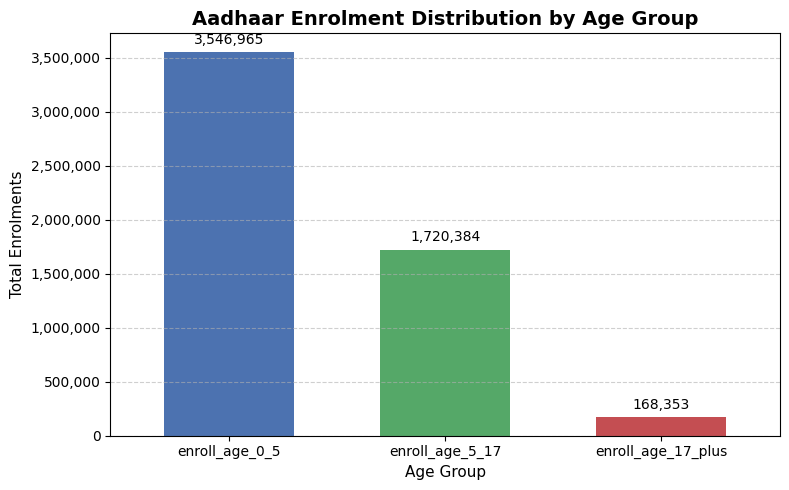

In [167]:
# Bar Chart: Enrolment Distribution by Age Group



plt.figure(figsize=(8, 5))

ax = enroll_age_sum.plot(
    kind='bar',
    color=['#4C72B0', '#55A868', '#C44E52'],
    width=0.6
)

plt.title(
    'Aadhaar Enrolment Distribution by Age Group',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Age Group', fontsize=11)
plt.ylabel('Total Enrolments', fontsize=11)

plt.xticks(rotation=0)

# Format Y-axis numbers
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

# Add value labels
ax.bar_label(
    ax.containers[0],
    fmt='{:,.0f}',
    padding=4,
    fontsize=10
)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [168]:
# Data Preparation 

df_demo_age = df_demo[['demo_age_5_17','demo_age_17_plus']]

# Sum enrollments by age group 
demo_age_sum = df_demo_age.sum()
demo_age_sum

demo_age_5_17        4863424
demo_age_17_plus    44431763
dtype: int64

Age Group VS Aadhar Demographic

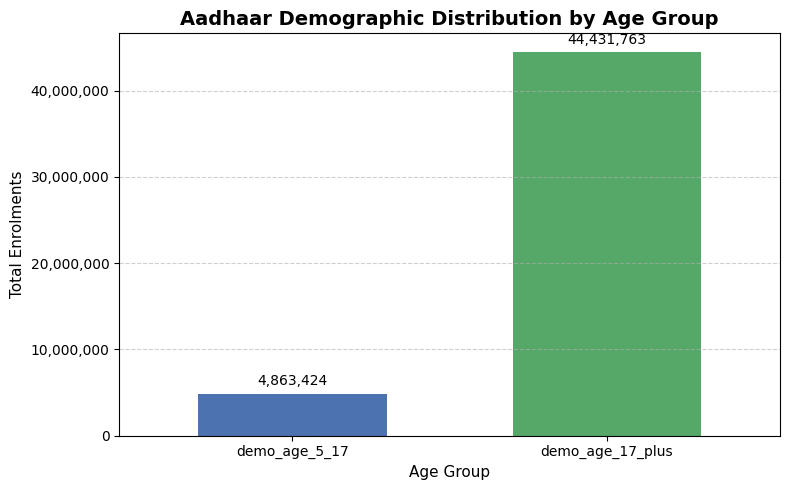

In [169]:
# Bar Chart: Demographic   Distribution by Age Group



plt.figure(figsize=(8, 5))

ax = demo_age_sum.plot(
    kind='bar',
    color=['#4C72B0', '#55A868', '#C44E52'],
    width=0.6
)

plt.title(
    'Aadhaar Demographic Distribution by Age Group',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Age Group', fontsize=11)
plt.ylabel('Total Enrolments', fontsize=11)

plt.xticks(rotation=0)

# Format Y-axis numbers
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

# Add value labels
ax.bar_label(
    ax.containers[0],
    fmt='{:,.0f}',
    padding=4,
    fontsize=10
)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [170]:
df_bio.head()

,date,state,district,pincode,bio_age_5_17,bio_age_17_plus,total_biometric_update,child_bio_ratio,adult_bio_ratio
0,2025-03-01,Haryana,Mahendragarh,123029,280,577,857,0.326721,0.673279
1,2025-03-01,Bihar,Madhepura,852121,144,369,513,0.280702,0.719298
2,2025-03-01,Jammu and Kashmir,Poonch,185101,643,1091,1734,0.370819,0.629181
3,2025-03-01,Bihar,Bhojpur,802158,256,980,1236,0.207120,0.792880
4,2025-03-01,Tamil Nadu,Madurai,625514,271,815,1086,0.249540,0.750460


Age Group VS Aadhar biometric 

In [171]:
# Data Preparation 

df_bio_sum = df_bio[['bio_age_5_17','bio_age_17_plus']]

# Sum enrollments by age group 
bio_age_sum = df_bio_sum.sum()
bio_age_sum

bio_age_5_17       34226855
bio_age_17_plus    35536240
dtype: int64

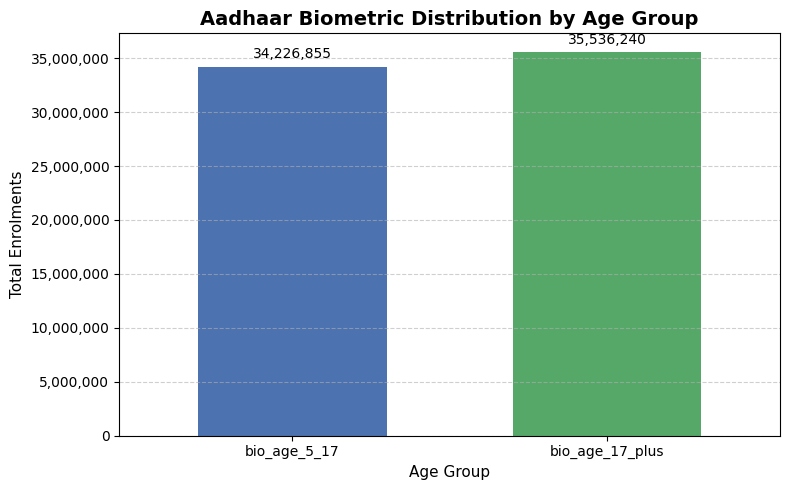

In [172]:
 #Bar Chart: Biometric  Distribution by Age Group



plt.figure(figsize=(8, 5))

ax = bio_age_sum.plot(
    kind='bar',
    color=['#4C72B0', '#55A868', '#C44E52'],
    width=0.6
)

plt.title(
    'Aadhaar Biometric Distribution by Age Group',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Age Group', fontsize=11)
plt.ylabel('Total Enrolments', fontsize=11)

plt.xticks(rotation=0)

# Format Y-axis numbers
ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

# Add value labels
ax.bar_label(
    ax.containers[0],
    fmt='{:,.0f}',
    padding=4,
    fontsize=10
)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Month vs aadhar Enrollment

<Figure size 2000x600 with 0 Axes>

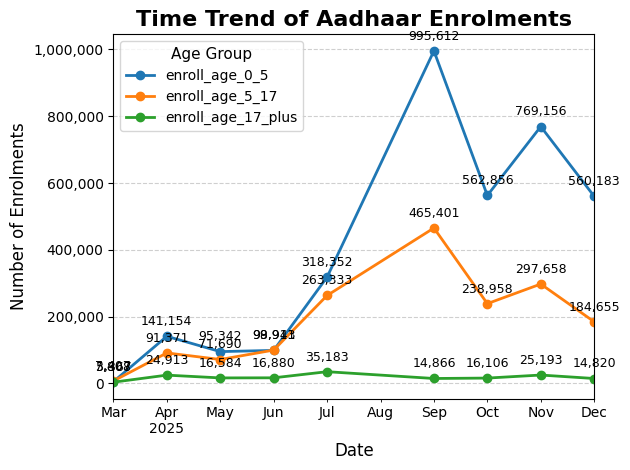

In [173]:
# Line Chart
# Aggregating enrolments by month
enroll_time = df_enroll.groupby(
    df_enroll['date'].dt.to_period('M')
)[['enroll_age_0_5', 'enroll_age_5_17', 'enroll_age_17_plus']].sum()

plt.figure(figsize=(20, 6))

ax = enroll_time.plot(
    linewidth=2,
    marker='o'
)

# Values show karna
for column in enroll_time.columns:
    for x, y in zip(enroll_time.index, enroll_time[column]):
        ax.annotate(
            f'{y:,.0f}',
            (x, y),
            textcoords='offset points',
            xytext=(0, 8),
            ha='center',
            fontsize=9
        )

ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

plt.title(
    'Time Trend of Aadhaar Enrolments',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Enrolments', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(
    title='Age Group',
    fontsize=10,
    title_fontsize=11
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Month vs aadhar biometric

<Figure size 2000x600 with 0 Axes>

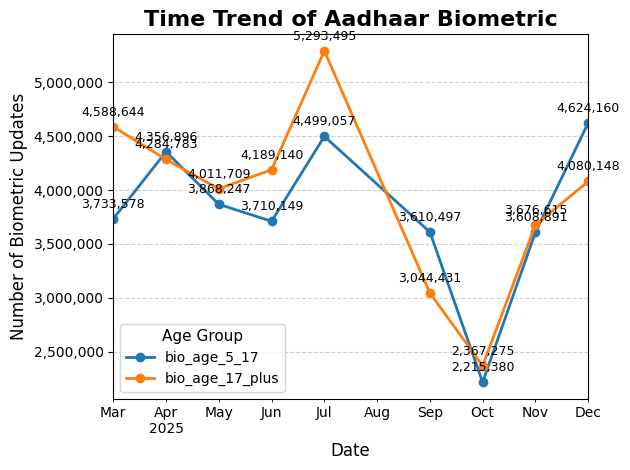

In [174]:
# Line Chart
# Aggregating biometric by month
bio_time = df_bio.groupby(
    df_bio['date'].dt.to_period('M')
)[['bio_age_5_17', 'bio_age_17_plus']].sum()

plt.figure(figsize=(20, 6))

ax = bio_time.plot(
    linewidth=2,
    marker='o'
)

# Values show karna
for column in bio_time.columns:
    for x, y in zip(bio_time.index, bio_time[column]):
        ax.annotate(
            f'{y:,.0f}',
            (x, y),
            textcoords='offset points',
            xytext=(0, 8),
            ha='center',
            fontsize=9
        )

ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

plt.title(
    'Time Trend of Aadhaar Biometric',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Biometric Updates', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(
    title='Age Group',
    fontsize=10,
    title_fontsize=11
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Month VS aadhar Demographic

<Figure size 2000x600 with 0 Axes>

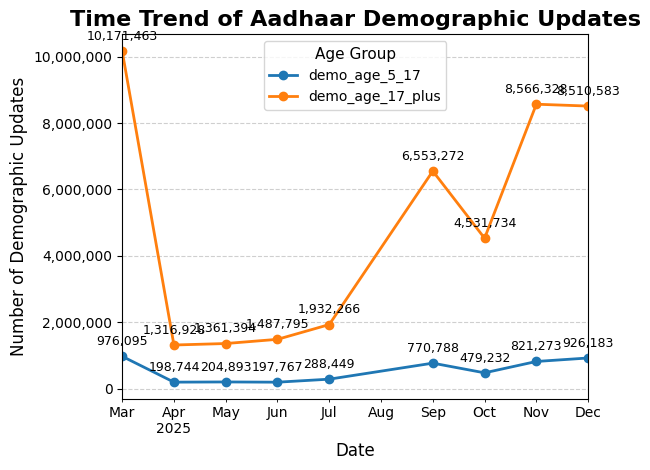

In [175]:
# Line Chart
# Aggregating demographic by date
demo_time = df_demo.groupby(
    df_demo['date'].dt.to_period('M')
)[['demo_age_5_17', 'demo_age_17_plus']].sum()

plt.figure(figsize=(20, 6))

ax = demo_time.plot(
    linewidth=2,
    marker='o'
)

# Values show karna
for column in demo_time.columns:
    for x, y in zip(demo_time.index, demo_time[column]):
        ax.annotate(
            f'{y:,.0f}',
            (x, y),
            textcoords='offset points',
            xytext=(0, 8),
            ha='center',
            fontsize=9
        )

ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

plt.title(
    'Time Trend of Aadhaar Demographic Updates',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Demographic Updates', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(
    title='Age Group',
    fontsize=10,
    title_fontsize=11
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Age Group vs (Enrollment , biometric, demographic )Updates

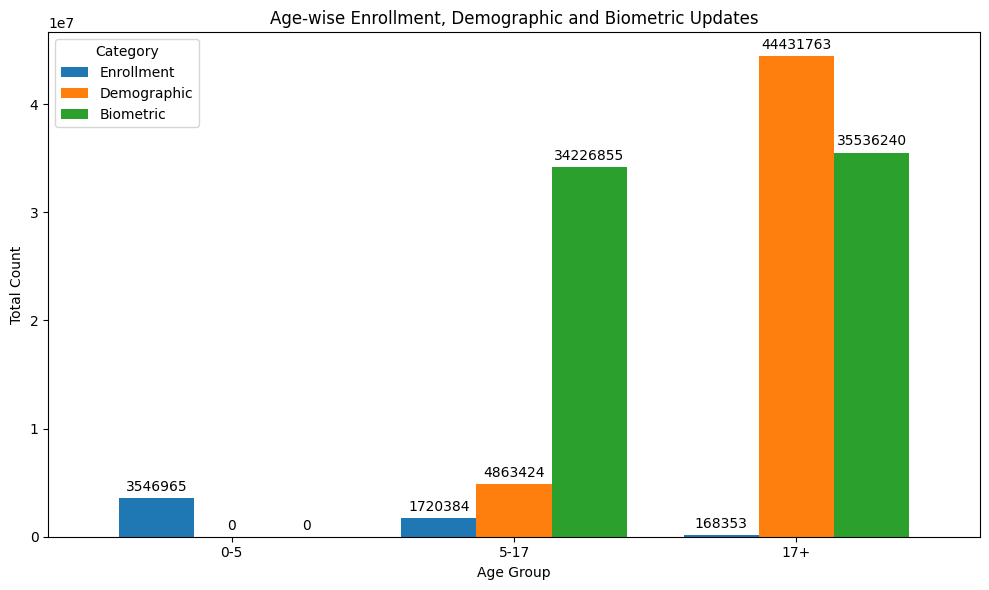

In [176]:
age_wise = pd.DataFrame({
    '0-5': [
        df_enroll['enroll_age_0_5'].sum(),
        0,
        0
    ],
    '5-17': [
        df_enroll['enroll_age_5_17'].sum(),
        df_demo['demo_age_5_17'].sum(),
        df_bio['bio_age_5_17'].sum()
    ],
    '17+': [
        df_enroll['enroll_age_17_plus'].sum(),
        df_demo['demo_age_17_plus'].sum(),
        df_bio['bio_age_17_plus'].sum()
    ]
}, index=['Enrollment', 'Demographic', 'Biometric'])

# Transpose
age_wise = age_wise.T






ax = age_wise.plot(
    kind='bar',
    figsize=(10, 6),
    width=0.8
)

# Bars ke upar numbers
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

ax.set_xlabel('Age Group')
ax.set_ylabel('Total Count')
ax.set_title('Age-wise Enrollment, Demographic and Biometric Updates')
ax.set_xticklabels(['0-5', '5-17', '17+'], rotation=0)

plt.legend(title='Category')
plt.tight_layout()
plt.show()

Month Vs (Enrollment,Demographic,Biometric) Updates

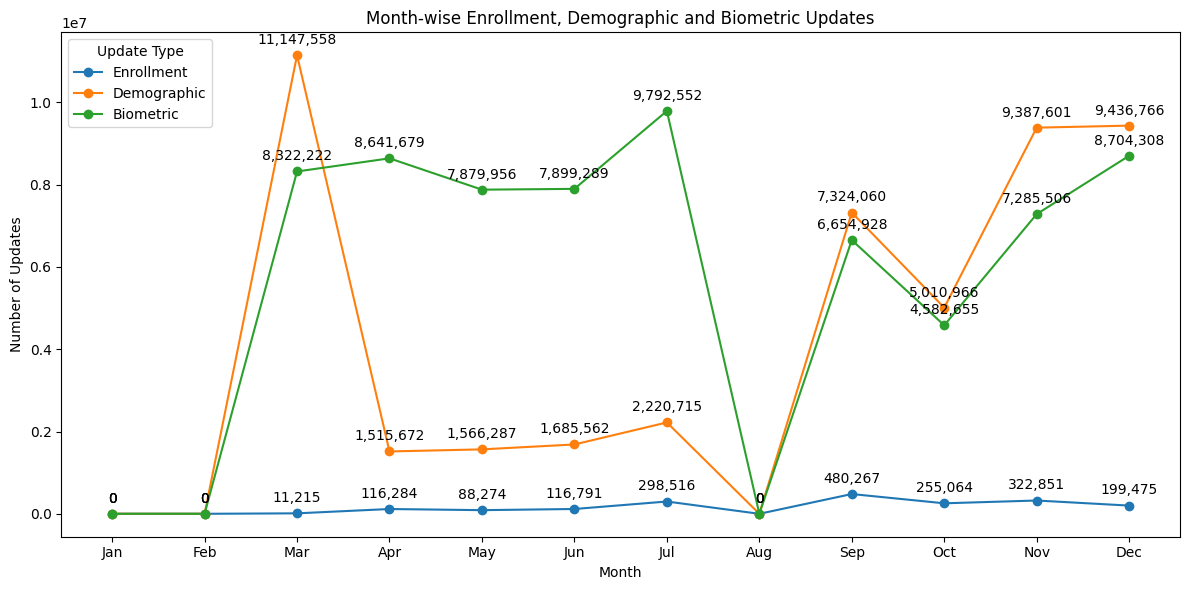

In [177]:


# Month-wise total
monthly_enroll = df_enroll.groupby(
    df_enroll['date'].dt.month
)['total_enrollment_update'].sum()

monthly_demo = df_demo.groupby(
    df_demo['date'].dt.month
)['total_demographic_update'].sum()

monthly_bio = df_bio.groupby(
    df_bio['date'].dt.month
)['total_biometric_update'].sum()


# Combine
monthly_data = pd.DataFrame({
    'Enrollment': monthly_enroll,
    'Demographic': monthly_demo,
    'Biometric': monthly_bio
}).fillna(0)


# 1-12 months ensure
monthly_data = monthly_data.reindex(range(1, 13), fill_value=0)


# Plot
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

ax = monthly_data.plot(
    kind='line',
    figsize=(12, 6),
    marker='o'
)

# Values show karna
for column in monthly_data.columns:
    for x, y in zip(monthly_data.index, monthly_data[column]):
        ax.annotate(
            f'{y:,.0f}',
            (x, y),
            textcoords='offset points',
            xytext=(0, 8),
            ha='center'
        )

plt.xticks(range(1, 13), months)
plt.xlabel('Month')
plt.ylabel('Number of Updates')
plt.title('Month-wise Enrollment, Demographic and Biometric Updates')
plt.legend(title='Update Type')
plt.tight_layout()
plt.show()